# W3D5 — Linear vs Convolutional: Two Ways to Read an Image — Lab

**Week 3 · Day 5 · Deep Learning & Neural Networks** · Lab

All week the data was a table. Today it is **Fashion-MNIST**: 28×28 grayscale images of
T-shirts, trousers, pullovers, dresses and six other garments. You load them with `torchvision`,
and you point two kinds of network at them.

- **Networks built from `nn.Linear` only.** A single linear layer, then an MLP with two hidden layers.
  Both begin with `nn.Flatten`, which turns the image into 784 numbers in a row. After that the
  network has no idea which pixels were next to each other.
- **A network built from `nn.Conv2d`.** It slides a small 3×3 window over the image and uses the same
  few weights at every position, so it keeps the picture.

Everything else stays the same: the week's `nn.Module`, `DataLoader` and five-line loop, one optimiser,
one learning rate, one budget and one seed. Then comes the experiment that shows *why* the two families
differ. You scramble every image's pixels in the same fixed way and train both again. One family does
not notice. The other loses its advantage.

Today's theory runs through all of it: Adam as the optimiser, early stopping that restores the best
weights, and the four curve shapes for reading every run.

You leave with `experiments.parquet` and `best_model.pt`. **The capstone brief is released today**, and
`experiments.parquet` is the shape of the experiment log it asks for.

**Time budget:** ~115 minutes. Sections 1–2 are the lab; Section 3 is a stretch you may finish at home.

<div dir="rtl" align="right">

# الأسبوع ٣ اليوم ٥ — الخطّي مقابل الالتفافي: طريقتان لقراءة صورة

**الأسبوع ٣ · اليوم ٥ · التعلّم العميق والشبكات العصبية** · معمل عملي

كانت البيانات طوال الأسبوع جدولًا. واليوم هي **Fashion-MNIST**: صور رمادية بحجم ٢٨×٢٨ لقمصان
وبنطالات وبلوفرات وفساتين وستة أصناف أخرى من الملابس. تُحمّلها بـ `torchvision`، ثم تُوجّه إليها
نوعين من الشبكات.

- **شبكات مبنيّة من `nn.Linear` وحدها.** طبقة خطية واحدة، ثم شبكة متعدّدة الطبقات (MLP) بطبقتين مخفيّتين.
  وكلتاهما تبدأ بـ `nn.Flatten`، الذي يحوّل الصورة إلى ٧٨٤ رقمًا في صف. ومن بعدها لا تعرف الشبكة أي
  البكسلات كانت متجاورة.
- **شبكة مبنيّة من `nn.Conv2d`.** تُمرّر نافذة صغيرة ٣×٣ على الصورة، وتستخدم الأوزان القليلة نفسها في
  كل موضع، فتحتفظ بالصورة.

وكل ما عدا ذلك يبقى كما هو: `nn.Module` و`DataLoader` وحلقة الأسطر الخمسة من هذا الأسبوع، ومُحسِّن واحد
ومعدّل تعلّم واحد وميزانية واحدة وبذرة واحدة. ثم تأتي التجربة التي تُريك *لماذا* تختلف العائلتان. تخلط
بكسلات كل صورة بالطريقة الثابتة نفسها وتدرّب الاثنتين من جديد. عائلة لا تلاحظ شيئًا، والأخرى تخسر
تفوّقها.

ونظرية اليوم حاضرة في كل ذلك: Adam مُحسِّنًا، والإيقاف المبكر (Early Stopping) الذي يستعيد أفضل
الأوزان، وأشكال المنحنيات الأربعة لقراءة كل تشغيل.

ستخرج بملفَّي `experiments.parquet` و`best_model.pt`. **وتُنشر كرّاسة مشروع التخرّج اليوم**،
و`experiments.parquet` هو شكل سجلّ التجارب الذي تطلبه.

**الزمن المتوقّع:** نحو ١١٥ دقيقة. القسمان الأول والثاني هما المعمل، والقسم الثالث إضافي يمكن إكماله في المنزل.

</div>

> **This is your lab notebook.** Work through the hints — they tell you what to do and where
> to look, not what to type. Stuck for more than ten minutes on one task? Open the `_guided`
> version. That is not cheating; sitting stuck in silence is the only mistake. The full
> solution is released at the end of the day.

<div dir="rtl" align="right">

> **هذا دفتر المعمل الخاص بك.** اعمل وفق الإرشادات — فهي تخبرك بما يجب فعله وأين تبحث، لا بما
> تكتبه حرفيًا. إذا توقّفت أكثر من عشر دقائق عند مهمة واحدة فافتح نسخة `_guided`؛ هذا ليس غشًّا،
> والخطأ الوحيد هو أن تبقى متوقّفًا بصمت. ويُنشر الحل الكامل في نهاية اليوم.

</div>

## Learning objectives

By the end of this lab you can:

- Say what `torchvision` is, and load Fashion-MNIST with `datasets.FashionMNIST`.
- Say what `ToTensor` and `Normalize` do to one pixel, why `Normalize` takes one mean and one standard
  deviation here, and why those numbers come from the training images only.
- Read an image batch's shape as `(batch, channels, height, width)`, and say what `nn.Flatten` does to it.
- Say what `nn.Conv2d`'s `in_channels`, `out_channels`, `kernel_size`, `stride` and `padding` do,
  and predict a layer's output size and parameter count before you run it.
- Say what `nn.MaxPool2d` does to a feature map's shape, and why it has no parameters.
- Train a linear classifier, an MLP and a CNN under identical conditions, with early stopping, and
  compare them on parameters, time per epoch and test accuracy.
- Show with a controlled experiment that a CNN's advantage comes from the arrangement of the pixels,
  and explain why an MLP cannot use that arrangement.

<div dir="rtl" align="right">

## أهداف التعلّم

بنهاية هذا المعمل ستكون قادرًا على:

- بيان ما هي `torchvision`، وتحميل Fashion-MNIST بـ `datasets.FashionMNIST`.
- بيان ما يفعله `ToTensor` و`Normalize` ببكسل واحد، ولماذا يأخذ `Normalize` هنا متوسطًا واحدًا وانحرافًا
  معياريًا واحدًا، ولماذا يأتي هذان الرقمان من صور التدريب وحدها.
- قراءة شكل دفعة الصور على أنه `(batch, channels, height, width)`، وبيان ما يفعله `nn.Flatten` بها.
- بيان ما تفعله وسائط `nn.Conv2d`: `in_channels` و`out_channels` و`kernel_size` و`stride`
  و`padding`، وتوقّع حجم مُخرَج الطبقة وعدد معاملاتها قبل تشغيلها.
- بيان ما يفعله `nn.MaxPool2d` بشكل خريطة الخصائص (Feature Map)، ولماذا لا معاملات له.
- تدريب مصنّف خطي وشبكة متعدّدة الطبقات وشبكة التفافية في ظروف متطابقة مع الإيقاف المبكر، ومقارنتها
  بعدد المعاملات وزمن الحقبة ودقة الاختبار.
- إثبات أن تفوّق الشبكة الالتفافية يأتي من ترتيب البكسلات، بتجربة مضبوطة، وشرح لماذا لا تستطيع الشبكة
  متعدّدة الطبقات استخدام ذلك الترتيب.

</div>


## About the data

**Dataset:** `fashion_mnist` — 70,000 grayscale images, 28×28 pixels, in ten clothing classes of
7,000 each: T-shirt/top, Trouser, Pullover, Dress, Coat, Sandal, Shirt, Sneaker, Bag, Ankle boot.
There are 60,000 training images and 10,000 test images. Han Xiao, Kashif Rasul and Roland Vollgraf
released it from Zalando Research in 2017 as a direct drop-in for the original MNIST digits, under
the MIT licence. `torchvision` downloads it the first time you run the setup — **about 30 MB**, so it
is quick even on class Wi-Fi. It is cached in this lab's `artefacts/` folder after that.

One item is one image plus one integer label from 0 to 9. The label is a **class index**, not a
one-hot vector, and `nn.CrossEntropyLoss` takes it as it is.

Why this dataset, and not more MNIST digits? MNIST digits are centred, clean and visually simple,
and an MLP already gets about 98% on them — so there is not much left for convolution to prove.
Fashion-MNIST keeps MNIST's size and shape but swaps in clothing silhouettes with real texture,
folds and ambiguous classes (shirt vs T-shirt vs pullover vs coat). That is enough for the way a
network reads an image to matter, while keeping the whole lab short enough for a laptop CPU.

Three splits, each with one job:

- **Training: 10,000 images**, drawn at random from the 60,000. That is about 1,000 per class, and
  it is enough for the gap between the two families to show. It also keeps a CNN run to about
  half a minute on a laptop CPU.
- **Validation: 5,000 other training images.** Early stopping watches these, and every comparison
  during the lab is made on them.
- **Test: the official 10,000.** Each model is scored on them **once**, at the end, in task 2.4.

**Watch out — two known problems.**

- **28×28 is tiny.** A shirt, a T-shirt, a pullover and a coat all look similar at this size even to
  a person, and a model's worst classes will be the ones you would get wrong too. Look at the images
  before you blame the model.
- **Some classes genuinely overlap.** The clothing categories come from Zalando's product tags, and
  the boundary between "shirt" and "T-shirt/top" is a shop decision as much as a visual one. That caps
  how high any model can score. It will not change today's comparison, because both families face the
  same ceiling, but it is a reminder that "ten clean classes" is a claim you check, not a label you
  trust.

<div dir="rtl" align="right">

## عن البيانات

**مجموعة البيانات:** `fashion_mnist` — ٧٠٬٠٠٠ صورة رمادية بحجم ٢٨×٢٨ بكسلًا، في عشر فئات ملابس من ٧٬٠٠٠
صورة لكلٍّ منها: قميص علوي، بنطال، بلوفر، فستان، معطف، صندل، قميص، حذاء رياضي، حقيبة، حذاء كاحل. منها
٦٠٬٠٠٠ صورة تدريب و١٠٬٠٠٠ صورة اختبار. أطلقها Han Xiao وKashif Rasul وRoland Vollgraf من Zalando
Research عام ٢٠١٧ بديلًا مباشرًا لأرقام MNIST الأصلية، تحت رخصة MIT. يُنزّلها `torchvision` أول مرة
تُشغّل فيها الإعداد — **نحو ٣٠ ميغابايت**، فهو سريع حتى على شبكة القاعة. وتُخزَّن بعد ذلك في مجلّد
`artefacts/` لهذا المعمل.

والعنصر الواحد صورة واحدة مع تصنيف صحيح واحد بين ٠ و٩. والتصنيف **رقم فئة** لا متّجه one-hot، ويأخذه
`nn.CrossEntropyLoss` كما هو.

ولماذا هذه المجموعة لا مزيدًا من أرقام MNIST؟ أرقام MNIST متمركزة ونظيفة وبسيطة بصريًا، وتبلغ عليها
الشبكة متعدّدة الطبقات نحو ٩٨٪ أصلًا، فلا يبقى للالتفاف الكثير ليُثبته. أما Fashion-MNIST فتُبقي حجم
MNIST وشكلها لكنها تستبدل بالأرقام ظلال ملابس فيها نسيج حقيقي وطيّات وفئات ملتبسة (قميص، قميص علوي،
بلوفر، معطف). وهذا كافٍ ليُحدث فرقًا في طريقة قراءة الشبكة للصورة، ويُبقي المعمل كلّه قصيرًا بما يكفي
لمعالج حاسوب محمول.

وثلاثة تقسيمات، لكلٍّ منها عمل واحد:

- **التدريب: ١٠٬٠٠٠ صورة** مسحوبة عشوائيًا من الستين ألفًا. أي نحو ألف صورة لكل فئة، وهذا يكفي ليظهر
  الفرق بين العائلتين. ويُبقي أيضًا تشغيل الشبكة الالتفافية في نحو نصف دقيقة على معالج حاسوب محمول.
- **التحقّق: ٥٬٠٠٠ صورة تدريب أخرى.** يراقبها الإيقاف المبكر، وكل مقارنة أثناء المعمل تُجرى عليها.
- **الاختبار: العشرة آلاف الرسمية.** يُقاس عليها كل نموذج **مرة واحدة** في النهاية، في المهمة ٢٫٤.

**انتبه — مشكلتان معروفتان.**

- **٢٨×٢٨ حجم صغير جدًا.** فالقميص والقميص العلوي والبلوفر والمعطف تتشابه بهذا الحجم حتى على الإنسان،
  وأسوأ فئات النموذج ستكون الفئات التي كنت ستخطئ فيها أنت أيضًا. فانظر في الصور قبل أن تلوم النموذج.
- **بعض الفئات تتداخل فعلًا.** فئات الملابس مأخوذة من بطاقات منتجات Zalando، والحدّ بين «قميص» و«قميص علوي»
  قرار متجر بقدر ما هو قرار بصري. وهذا يسقف الدرجة القصوى لأي نموذج. ولن يغيّر مقارنة اليوم، لأن العائلتين
  تواجهان السقف نفسه، لكنه تذكير بأن «عشر فئات نظيفة» ادعاء تتحقّق منه، لا وصف تثق به.

</div>


## `torchvision` in one page

PyTorch knows about tensors and layers, but nothing about images. **`torchvision`** is its companion
library for vision. Today you use two of its parts:

- **`torchvision.datasets`** — standard datasets, ready to use. `datasets.FashionMNIST` downloads
  Fashion-MNIST and gives it to you as a `Dataset`, the same interface as Thursday's `TensorDataset`.
- **`torchvision.transforms`** — functions that turn an image into a tensor the network can use.

(A third part, `torchvision.models`, holds famous pre-trained networks. You meet it in W4D5.)

**Loading the data.** `datasets.FashionMNIST(root, train, download, transform)`:

- `root` — the folder the files are stored in.
- `train` — `True` for the 60,000 training images, `False` for the 10,000 test images.
- `download` — `True` downloads the files if they are missing.
- `transform` — what to do to every image as it is read.

Without a `transform`, each item is a PIL image (Python's standard image object) and an integer label.
A network cannot use a PIL image, so the transform is what makes the dataset useful.

**The two transforms today.**

- **`transforms.ToTensor()`** turns the image into a `float32` tensor of shape **(channels, height,
  width)** — `(1, 28, 28)` here — with every pixel divided by 255, so values lie in `[0, 1]`.
- **`transforms.Normalize(mean, std)`** computes `(x − mean) / std` **for each channel**. A grayscale
  image has one channel, so it takes one mean and one std. The result is inputs centred on zero,
  which is what the network's initialisation expects.

**`transforms.Compose([ToTensor(), Normalize(...)])`** runs them in order. `ToTensor` must come first,
because `Normalize` works on tensors.

**One rule:** the mean and std are computed from **the training images only**. Using the test images
would leak information about the test set into your preprocessing — Week 2's leakage rule, applied to
images.

<div dir="rtl" align="right">

## `torchvision` في صفحة واحدة

يعرف PyTorch المُوتِّرات (Tensors) والطبقات، ولا يعرف شيئًا عن الصور. و**`torchvision`** هي مكتبته المرافقة
للرؤية الحاسوبية. وتستخدم اليوم جزأين منها:

- **`torchvision.datasets`** — مجموعات بيانات معيارية جاهزة للاستخدام. فـ `datasets.FashionMNIST`
  تُنزّل Fashion-MNIST وتعطيك إياها كـ `Dataset`، الواجهة نفسها التي رأيتها في `TensorDataset` يوم الخميس.
- **`torchvision.transforms`** — دوال تحوّل الصورة إلى مُوتِّر تستطيع الشبكة استخدامه.

(وجزء ثالث، `torchvision.models`، فيه شبكات مشهورة مُدرَّبة مسبقًا. وستلتقي به في الأسبوع ٤ اليوم ٥.)

**تحميل البيانات.** `datasets.FashionMNIST(root, train, download, transform)`:

- `root` — المجلّد الذي تُخزَّن فيه الملفات.
- `train` — `True` لصور التدريب الستين ألفًا، و`False` لصور الاختبار العشرة آلاف.
- `download` — `True` تُنزّل الملفات إن كانت ناقصة.
- `transform` — ما يُفعل بكل صورة حين تُقرأ.

وبلا `transform` يكون كل عنصر صورة PIL (كائن الصور المعياري في Python) مع تصنيف صحيح. ولا تستطيع الشبكة
استخدام صورة PIL، فالتحويل هو ما يجعل مجموعة البيانات نافعة.

**التحويلان اليوم.**

- **`transforms.ToTensor()`** يحوّل الصورة إلى مُوتِّر بنوع `float32` شكله **(قنوات، ارتفاع، عرض)** — أي
  `(1, 28, 28)` هنا — وكل بكسل مقسوم على ٢٥٥، فتقع القيم في `[0, 1]`.
- **`transforms.Normalize(mean, std)`** يحسب `(x − mean) / std` **لكل قناة**. وللصورة الرمادية قناة واحدة،
  فيأخذ متوسطًا واحدًا وانحرافًا واحدًا. والنتيجة مُدخلات متمركزة حول الصفر، وهذا ما تتوقّعه تهيئة الشبكة.

**`transforms.Compose([ToTensor(), Normalize(...)])`** يُشغّلهما بالترتيب. ويجب أن يأتي `ToTensor` أولًا، لأن
`Normalize` يعمل على المُوتِّرات.

**وقاعدة واحدة:** يُحسب المتوسط والانحراف من **صور التدريب وحدها**. فاستخدام صور الاختبار يُسرّب معلومات عن
مجموعة الاختبار إلى المعالجة المسبقة — قاعدة التسرّب من الأسبوع الثاني، مطبّقةً على الصور.

</div>


## Setup

Run the cell below first. It downloads Fashion-MNIST (first run only) and draws the three splits. Then it
does the preprocessing in the order the previous section described:

1. Load the datasets with `ToTensor` only, and stack the 10,000 training images into one tensor.
2. Compute the single channel mean and std **from those training images**.
3. Swap in the full transform, `ToTensor` then `Normalize`, and stack all three splits again.

Stacking is the same choice MNIST would have needed. A `torchvision` dataset runs its transform every
time an image is read, and today you read the same 10,000 images many times. When a dataset fits in
memory, transforming once and training from a `TensorDataset` is the standard move. Here it is about
80 MB for the three splits. When it does not fit, the `DataLoader` reads and transforms from disk as
it goes, which is what week 4 does with real photographs.

<div dir="rtl" align="right">

## الإعداد

شغّل الخليّة أدناه أولًا. تُنزّل Fashion-MNIST (في أول تشغيل فقط) وتسحب التقسيمات الثلاثة. ثم تُجري المعالجة
المسبقة بالترتيب الذي وصفه القسم السابق:

١. تُحمّل مجموعات البيانات بـ `ToTensor` وحده، وترصّ صور التدريب العشرة آلاف في مُوتِّر واحد.
٢. تحسب متوسط القناة الواحد وانحرافها **من صور التدريب تلك**.
٣. تضع التحويل الكامل، `ToTensor` ثم `Normalize`، وترصّ التقسيمات الثلاثة من جديد.

والرصّ هو الاختيار نفسه الذي كانت MNIST ستحتاجه. فمجموعة `torchvision` تُشغّل تحويلها في كل مرة تُقرأ فيها
صورة، وستقرأ اليوم صور التدريب العشرة آلاف نفسها مرات كثيرة. وحين تتّسع الذاكرة للبيانات، فالتحويل مرة
واحدة ثم التدريب من `TensorDataset` هو الخطوة المعيارية. وهي هنا نحو ٨٠ ميغابايت للتقسيمات الثلاثة. وحين
لا تتّسع، يقرأ `DataLoader` من القرص ويحوّل وهو يمضي، وهذا ما يفعله الأسبوع الرابع بالصور الحقيقية.

</div>


In [1]:
# === AIEP portable setup — works locally (Miniconda + uv) and on Google Colab ===============
try:
    import aiep
except ImportError:
    import subprocess, sys
    from pathlib import Path
    _local = next((p / "shared" for p in [Path.cwd(), *Path.cwd().parents]
                   if (p / "shared" / "aiep").is_dir()), None)
    if _local:
        sys.path.insert(0, str(_local))
    else:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q",
                               "git+https://github.com/0xRush/AIEP_Olo_student.git#subdirectory=shared"])
    import aiep

from aiep.env import ensure, seed_everything, versions
from aiep.paths import ARTEFACT_DIR
from aiep.checks import check, report

ensure("torch", "torchvision", "scikit-learn", "matplotlib", "pyarrow")
seed_everything(42)

import copy
import math
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset, TensorDataset
from torchvision import datasets, transforms

from aiep.viz import use_course_style, PALETTE, plot_grid, plot_confusion_matrix
use_course_style()

SEED = 42
N_TRAIN, N_VAL = 10_000, 5_000
FMNIST_ROOT = ARTEFACT_DIR / "torchvision"

# 1) The datasets, with ToTensor only. download=True fetches ~30 MB the first time, and after that
#    finds the files already in FMNIST_ROOT and does nothing.
fmnist_train = datasets.FashionMNIST(FMNIST_ROOT, train=True, download=True,
                                     transform=transforms.ToTensor())
fmnist_test = datasets.FashionMNIST(FMNIST_ROOT, train=False, download=True,
                                    transform=transforms.ToTensor())
CLASSES = fmnist_train.classes   # ['T-shirt/top', 'Trouser', 'Pullover', ...] — index i is label i


def stack(dataset, indices):
    """Run the dataset's transform once per image; return (images, labels) as two tensors."""
    loader = DataLoader(Subset(dataset, list(indices)), batch_size=1_000)
    images, labels = zip(*loader)
    return torch.cat(images), torch.cat(labels)


order = torch.randperm(len(fmnist_train), generator=torch.Generator().manual_seed(SEED))
train_idx = order[:N_TRAIN].tolist()
val_idx = order[N_TRAIN:N_TRAIN + N_VAL].tolist()

# 2) One mean and one std per channel, from the TRAINING images only. dim=(0, 2, 3) averages over
#    images, rows and columns, and leaves the channel axis: one number each for grayscale.
unnormalised, _ = stack(fmnist_train, train_idx)
FMNIST_MEAN = unnormalised.mean(dim=(0, 2, 3)).tolist()
FMNIST_STD = unnormalised.std(dim=(0, 2, 3)).tolist()
del unnormalised

# 3) The transform every network sees: PIL image -> (1, 28, 28) float in [0, 1] -> per-channel z-score.
TRANSFORM = transforms.Compose([transforms.ToTensor(),
                                transforms.Normalize(FMNIST_MEAN, FMNIST_STD)])
fmnist_train.transform = TRANSFORM   # same files on disk, new transform
fmnist_test.transform = TRANSFORM

X_train, y_train = stack(fmnist_train, train_idx)
X_val, y_val = stack(fmnist_train, val_idx)
X_test, y_test = stack(fmnist_test, range(len(fmnist_test)))


def show(images):
    """Undo Normalize so a batch can be drawn: z-scores back to [0, 1] pixels."""
    mean = torch.tensor(FMNIST_MEAN).view(1, 1, 1)
    std = torch.tensor(FMNIST_STD).view(1, 1, 1)
    return (images * std + mean).clamp(0, 1)


print("Fashion-MNIST: 70,000 grayscale 28x28 images, 10 clothing classes, Zalando Research 2017, MIT.")
print(f"\nclasses: {CLASSES}")
print(f"channel mean (grayscale), training images only: {[round(m, 4) for m in FMNIST_MEAN]}")
print(f"channel std  (grayscale), training images only: {[round(s, 4) for s in FMNIST_STD]}")
print(f"\ntrain {tuple(X_train.shape)} | val {tuple(X_val.shape)} | test {tuple(X_test.shape)} "
      f"| {X_train.dtype}")
print(f"labels are class indices, {y_train.dtype}: {y_train[:12].tolist()}")
print("\n", versions())

Fashion-MNIST: 70,000 grayscale 28x28 images, 10 clothing classes, Zalando Research 2017, MIT.

classes: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
channel mean (grayscale), training images only: [0.2869]
channel std  (grayscale), training images only: [0.3535]

train (10000, 1, 28, 28) | val (5000, 1, 28, 28) | test (10000, 1, 28, 28) | torch.float32
labels are class indices, torch.int64: [9, 2, 5, 0, 5, 1, 3, 5, 0, 1, 1, 4]

 python 3.11.16 | numpy 2.0.2 | pandas 3.0.5 | scikit-learn 1.9.0 | torch 2.13.0 | transformers 5.15.1


## Section 1 — Warm-up: an image as a tensor, and a convolution layer up close  (≈25 min)

Everything in this section already works. Run it, read the shapes, and change the one thing each cell
suggests.

The first cell follows one image from disk to network. It starts as the raw array `torchvision`
stored, becomes a PIL image, goes through `ToTensor`, then through `Normalize`, then into a batch from a
`DataLoader`, and finally through `nn.Flatten`. At each stage it prints the shape and the value of one
pixel, so you can see which step did what.

<div dir="rtl" align="right">

## القسم الأول — التهيئة: الصورة مُوتِّرًا، وطبقة التفافية عن قرب (نحو ٢٥ دقيقة)

كل ما في هذا القسم يعمل أصلًا. شغّله، واقرأ الأشكال، وغيّر الشيء الواحد الذي تقترحه كل خليّة.

تتبع الخليّة الأولى صورة واحدة من القرص إلى الشبكة. تبدأ مصفوفةً خامًا كما خزّنتها `torchvision`، ثم
تصير صورة PIL، ثم تمرّ في `ToTensor`، ثم في `Normalize`، ثم تدخل دفعةً من `DataLoader`، وأخيرًا تمرّ في
`nn.Flatten`. وفي كل مرحلة تطبع الشكل وقيمة بكسل واحد، فترى أي خطوة فعلت ماذا.

</div>


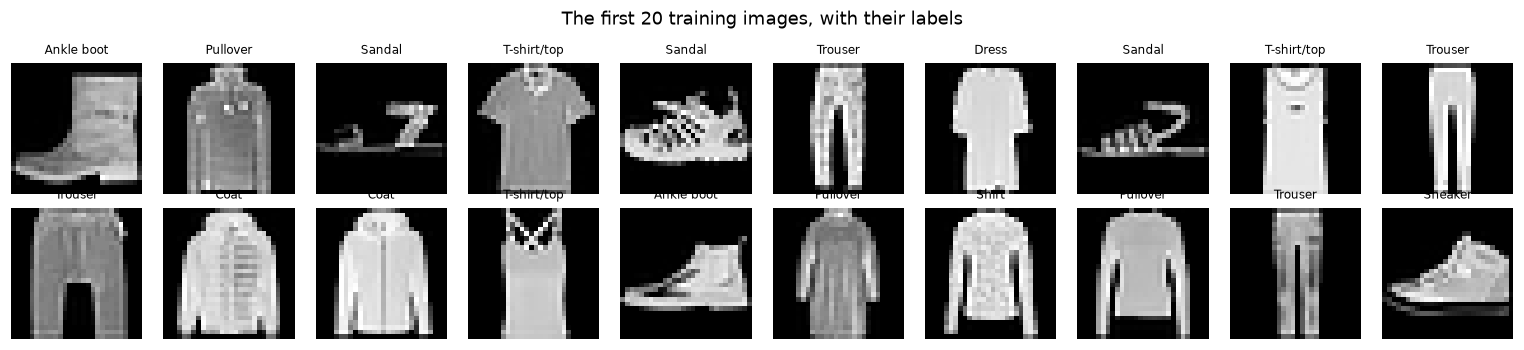

fmnist_train.data: (60000, 28, 28) torch.uint8   <- (images, height, width)
one raw image:     (28, 28), pixel (14,14) = 156
as a PIL image:    mode 'L', size (28, 28), label 9 = Ankle boot
after ToTensor:    (1, 28, 28) torch.float32, pixel = [0.6118]   <- channel first, divided by 255
after Normalize:   (1, 28, 28), pixel = [0.919]   <- (value - mean) / std

the single channel of the 10,000 training images, after Normalize:
  grayscale: mean +0.0000, std 1.0000

one batch:         images (64, 1, 28, 28) = (batch, channels, height, width), labels (64,)
after nn.Flatten:  (64, 784)   <- 1 x 28 x 28 = 784 numbers, no picture

images per class in the training 10,000: [980, 979, 1061, 974, 1046, 1055, 984, 993, 957, 971]


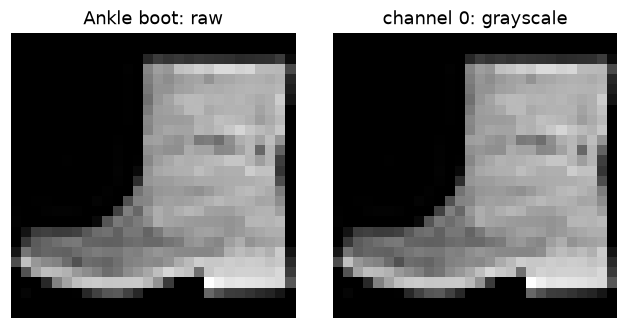

In [2]:
from PIL import Image

plot_grid(show(X_train[:20]), [CLASSES[i] for i in y_train[:20]], n_cols=10,
          title="The first 20 training images, with their labels")
plt.show()

index = train_idx[0]
raw = fmnist_train.data[index].numpy()      # how torchvision stores Fashion-MNIST: a torch tensor
pil = Image.fromarray(raw, mode="L")        # mode 'L' = 8-bit grayscale
as_tensor = transforms.ToTensor()(pil)
normalised = TRANSFORM(pil)
row, col = 14, 14                           # the pixel we follow — change it and rerun

print(f"fmnist_train.data: {tuple(fmnist_train.data.shape)} {fmnist_train.data.dtype}   "
      f"<- (images, height, width)")
print(f"one raw image:     {raw.shape}, pixel ({row},{col}) = {int(raw[row, col])}")
print(f"as a PIL image:    mode {pil.mode!r}, size {pil.size}, label {int(fmnist_train.targets[index])} "
      f"= {CLASSES[int(fmnist_train.targets[index])]}")
print(f"after ToTensor:    {tuple(as_tensor.shape)} {as_tensor.dtype}, pixel = "
      f"{[round(v, 4) for v in as_tensor[:, row, col].tolist()]}   <- channel first, divided by 255")
print(f"after Normalize:   {tuple(normalised.shape)}, pixel = "
      f"{[round(v, 4) for v in normalised[:, row, col].tolist()]}   <- (value - mean) / std")

print("\nthe single channel of the 10,000 training images, after Normalize:")
print(f"  grayscale: mean {X_train[:, 0].mean():+.4f}, std {X_train[:, 0].std():.4f}")

xb, yb = next(iter(DataLoader(TensorDataset(X_train, y_train), batch_size=64)))
print(f"\none batch:         images {tuple(xb.shape)} = (batch, channels, height, width), "
      f"labels {tuple(yb.shape)}")
print(f"after nn.Flatten:  {tuple(nn.Flatten()(xb).shape)}   <- 1 x 28 x 28 = 784 numbers, "
      f"no picture")
print(f"\nimages per class in the training 10,000: {torch.bincount(y_train).tolist()}")

fig, axes = plt.subplots(1, 2, figsize=(6, 3))
axes[0].imshow(raw, cmap="gray", vmin=0, vmax=255)
axes[0].set_title(f"{CLASSES[int(fmnist_train.targets[index])]}: raw")
axes[1].imshow(as_tensor[0], cmap="gray", vmin=0, vmax=1)
axes[1].set_title("channel 0: grayscale")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

**Change one thing:** move `row, col` to a pixel in the background (near a corner) and rerun. Then
check the arithmetic yourself: `(raw / 255 − mean) / std` should give the printed `Normalize` value.
There is only one channel here, so one grid is the whole picture — but a convolution layer still reads
it the same way it would read three stacked grids. W4D1 revisits colour.

<div dir="rtl" align="right">

**غيّر شيئًا واحدًا:** انقل `row, col` إلى بكسل في الخلفية (قرب زاوية) وأعِد التشغيل. ثم تحقّق من الحساب
بنفسك: `(raw / 255 − mean) / std` يجب أن يُعطي قيمة `Normalize` المطبوعة. وهنا قناة واحدة فقط،
فالشبكة الواحدة هي الصورة كلها — لكنّ الطبقة الالتفافية ما زالت تقرؤها كما تقرأ ثلاث شبكات مرصوصة.
ويعود الأسبوع ٤ اليوم ١ إلى الألوان.

</div>


### Task 1.1 — `nn.Conv2d`, the fundamentals

On Thursday, `nn.Linear(in_features, out_features)` had two arguments. `nn.Conv2d` has five that matter:

```python
nn.Conv2d(in_channels, out_channels, kernel_size, stride=1, padding=0)
```

- **`in_channels`** — channels coming in: 1 for a grayscale image, or the previous conv layer's
  `out_channels`.
- **`out_channels`** — how many **filters** the layer learns. Each filter produces one output channel,
  called a **feature map**.
- **`kernel_size`** — the filter's size: `3` means a 3×3 window.
- **`stride`** — how far the window moves each step. `2` halves the height and width.
- **`padding`** — zeros added around the border. With a 3×3 kernel, `padding=1` keeps a 28×28 image
  at 28×28.

Two formulas let you predict any layer before you run it:

- **Output size:** `(n + 2·padding − kernel_size) // stride + 1`
- **Parameters:** `out_channels × in_channels × kernel_size × kernel_size` weights, plus one bias per
  output channel.

**`nn.MaxPool2d(2)`** keeps the largest value in each 2×2 block, so it halves the height and width. It
has no parameters.

The cell below builds one layer, checks both formulas against real tensors, and computes one output
number by hand. That number is the filter multiplied by one 3×3 patch of the image, summed, plus the
bias — Thursday's `x @ W.T + b`, applied to 9 numbers instead of all 784, with the **same** weights at
every position. W4D1 does this by hand for a whole image.

<div dir="rtl" align="right">

### المهمة ١٫١ — `nn.Conv2d`، الأساسيات

كان لـ `nn.Linear(in_features, out_features)` يوم الخميس وسيطان. أما `nn.Conv2d` فله خمسة وسائط مهمّة:

```python
nn.Conv2d(in_channels, out_channels, kernel_size, stride=1, padding=0)
```

- **`in_channels`** — القنوات الداخلة: ١ لصورة رمادية، أو `out_channels` للطبقة الالتفافية السابقة.
- **`out_channels`** — عدد **الفلاتر** التي تتعلّمها الطبقة. وكل فِلتر يُنتج قناة مُخرَج واحدة تُسمّى **خريطة
  الخصائص** (Feature Map).
- **`kernel_size`** — حجم الفِلتر: `3` تعني نافذة ٣×٣.
- **`stride`** — الخطوة (Stride): كم تتحرّك النافذة في كل مرة. و`2` تُنصّف الارتفاع والعرض.
- **`padding`** — الحشو (Padding): أصفار تُضاف حول الحدود. ومع نواة ٣×٣ يُبقي `padding=1` صورة ٢٨×٢٨ على
  ٢٨×٢٨.

ومعادلتان تتيحان لك توقّع أي طبقة قبل تشغيلها:

- **حجم المُخرَج:** `(n + 2·padding − kernel_size) // stride + 1`
- **المعاملات:** `out_channels × in_channels × kernel_size × kernel_size` وزنًا، زائد انحياز واحد لكل قناة
  مُخرَج.

و**`nn.MaxPool2d(2)`** يُبقي أكبر قيمة في كل كتلة ٢×٢، فيُنصّف الارتفاع والعرض. ولا معاملات له.

وتبني الخليّة أدناه طبقة واحدة، وتتحقّق من المعادلتين على مُوتِّرات حقيقية، وتحسب رقمًا واحدًا من المُخرَج
باليد. وذلك الرقم هو الفِلتر مضروبًا في رقعة واحدة ٣×٣ من الصورة، مجموعًا، زائد الانحياز — أي `x @ W.T + b`
من يوم الخميس، مطبّقًا على ٩ أرقام بدل ٧٨٤ كلها، وبالأوزان **نفسها** في كل موضع. ويفعل الأسبوع ٤ اليوم ١
ذلك باليد لصورة كاملة.

</div>


In [3]:
conv = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, stride=1, padding=1)
print(conv)
print(f"weight {tuple(conv.weight.shape)} = (out_channels, in_channels, kernel_h, kernel_w)")
print(f"bias   {tuple(conv.bias.shape)}   = one per output channel")
print(f"parameters: 16 x 1 x 3 x 3 + 16 = {16 * 1 * 3 * 3 + 16}, "
      f"counted: {sum(p.numel() for p in conv.parameters())}")

xb = X_train[:8]
out = conv(xb)
print(f"\ninput {tuple(xb.shape)} -> output {tuple(out.shape)}: 16 feature maps per image")

# One output number, by hand: the filter times one 3x3 patch, summed, plus the bias.
f, i, j = 5, 10, 12
padded = nn.functional.pad(xb, (1, 1, 1, 1))       # what padding=1 does before sliding
patch = padded[0, :, i:i + 3, j:j + 3]              # (1, 3, 3): the one channel, a 3x3 window
by_hand = (conv.weight[f] * patch).sum() + conv.bias[f]
print(f"\nfilter {f} at row {i}, column {j}: by hand {by_hand.item():+.6f}, "
      f"by the layer {out[0, f, i, j].item():+.6f}")


def conv_out(n, kernel_size, stride=1, padding=0):
    return (n + 2 * padding - kernel_size) // stride + 1


print(f"\n{'kernel':>6}{'stride':>7}{'padding':>8}{'predicted':>11}{'actual':>8}{'params':>8}")
for k, s, p in [(3, 1, 0), (3, 1, 1), (5, 1, 2), (3, 2, 1), (1, 1, 0), (7, 2, 3)]:
    layer = nn.Conv2d(1, 16, kernel_size=k, stride=s, padding=p)
    actual = layer(xb).shape[-1]
    params = sum(q.numel() for q in layer.parameters())
    print(f"{k:>6}{s:>7}{p:>8}{conv_out(28, k, s, p):>11}{actual:>8}{params:>8}")

pool = nn.MaxPool2d(2)
print(f"\n{pool}")
print(f"MaxPool2d(2): {tuple(out.shape)} -> {tuple(pool(out).shape)}, "
      f"parameters: {sum(p.numel() for p in pool.parameters())}")

dense_weights = (1 * 28 * 28) * (16 * 28 * 28)
print(f"\nan nn.Linear producing the same 16 x 28 x 28 outputs from 1 x 28 x 28 inputs would need "
      f"{dense_weights:,} weights")
print(f"the conv layer uses {16 * 1 * 3 * 3:,}: every output looks at 9 inputs, not 784, and "
      f"every position shares the same filter")

Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
weight (16, 1, 3, 3) = (out_channels, in_channels, kernel_h, kernel_w)
bias   (16,)   = one per output channel
parameters: 16 x 1 x 3 x 3 + 16 = 160, counted: 160

input (8, 1, 28, 28) -> output (8, 16, 28, 28): 16 feature maps per image

filter 5 at row 10, column 12: by hand -0.370429, by the layer -0.370429

kernel stride padding  predicted  actual  params
     3      1       0         26      26     160
     3      1       1         28      28     160
     5      1       2         28      28     416
     3      2       1         14      14     160
     1      1       0         28      28      32
     7      2       3         14      14     800

MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
MaxPool2d(2): (8, 16, 28, 28) -> (8, 16, 14, 14), parameters: 0

an nn.Linear producing the same 16 x 28 x 28 outputs from 1 x 28 x 28 inputs would need 9,834,496 weights
the conv layer uses 144: every o

**Change one thing:** set `padding=0` on the first line and rerun. The output shrinks to 26×26, and the
hand computation needs `padded` replaced by `xb`. Then try `stride=2`. Before each run, predict the
shape with `conv_out`.

The last two lines are the idea the whole lab measures. A convolution layer is a linear layer with two
assumptions built in:

- **Locality.** Each output depends on a small neighbourhood of the input, not on the whole image.
- **Parameter sharing.** The same filter is used at every position, so a pattern learned in one corner
  is recognised in every corner.

Those two assumptions take the layer from 9.8 million weights to 144. The question for Section 2 is
whether they are also *true* about these images — and what happens when you make them false.

<div dir="rtl" align="right">

**غيّر شيئًا واحدًا:** اضبط `padding=0` في السطر الأول وأعِد التشغيل. يصغر المُخرَج إلى ٢٦×٢٦، ويحتاج الحساب
اليدوي أن تستبدل `padded` بـ `xb`. ثم جرّب `stride=2`. وقبل كل تشغيل، توقّع الشكل بـ `conv_out`.

والسطران الأخيران هما الفكرة التي يقيسها المعمل كله. فالطبقة الالتفافية طبقة خطية فيها افتراضان مبنيّان:

- **المحلية.** كل مُخرَج يعتمد على جوار صغير من المُدخَل، لا على الصورة كلها.
- **مشاركة المعاملات (Parameter Sharing).** الفِلتر نفسه يُستخدم في كل موضع، فالنمط الذي تتعلّمه في زاوية
  تتعرّف عليه في كل الزوايا.

وهذان الافتراضان ينقلان الطبقة من ٩٫٨ مليون وزن إلى ١٤٤. وسؤال القسم الثاني: هل هما أيضًا *صحيحان* في هذه
الصور — وماذا يحدث حين تجعلهما خاطئين؟

</div>


## Section 2 — Core: five tasks  (≈60 min)

1. One training function, with early stopping, that every model goes through. Test it on a single
   linear layer.
2. The MLP: `nn.Linear` layers only, ~535,000 parameters.
3. The CNN: `nn.Conv2d` layers, a shape trace, and about 130,000 parameters.
4. The comparison: one table, one figure, and the test set, once.
5. Scramble the pixels, retrain both, and find out which network was using the picture.

The rule that makes this a comparison and not three anecdotes: **every model goes through the same
`fit()`**, with the same optimiser, learning rate, batch size, epoch budget, patience and seed. The
architecture is the only thing that changes.

<div dir="rtl" align="right">

## القسم الثاني — الأساسي: خمس مهام (نحو ٦٠ دقيقة)

١. دالة تدريب واحدة مع الإيقاف المبكر، يمرّ فيها كل نموذج. وتجرّبها على طبقة خطية واحدة.
٢. الشبكة متعدّدة الطبقات: طبقات `nn.Linear` وحدها، و~٥٣٥٬٠٠٠ معامل.
٣. الشبكة الالتفافية: طبقات `nn.Conv2d`، وتتبّع للأشكال، ونحو ١٣٠٬٠٠٠ معامل.
٤. المقارنة: جدول واحد وشكل واحد، ومجموعة الاختبار مرة واحدة.
٥. اخلط البكسلات، وأعِد تدريب الاثنتين، واكتشف أي شبكة كانت تستخدم الصورة.

والقاعدة التي تجعل هذا مقارنة لا ثلاث حكايات: **كل نموذج يمرّ في `fit()` نفسها**، بالمُحسِّن نفسه ومعدّل
التعلّم نفسه وحجم الدفعة نفسه وميزانية الحقب نفسها والصبر نفسه والبذرة نفسها. والمعمارية هي الشيء الوحيد
الذي يتغيّر.

</div>


### The shared helpers

Three small functions, already written. They are the same for every model.

- **`count_parameters(model)`** — the number the comparison table is built around.
- **`evaluate(model, X, y)`** — mean loss and accuracy under `model.eval()` and `torch.no_grad()`. It
  goes through the data **1,000 images at a time**. It has to: the CNN's first layer produces
  32 × 28 × 28 numbers per image, so all 10,000 test images at once would need about 1 GB for that
  one layer. The MLP would survive it and the CNN might not, and a helper that only works for one
  family is no good for a comparison.
- **`predict(model, X)`** — the predicted class for every image, in the same batches.

The loss is `nn.CrossEntropyLoss`, the ten-class relative of Thursday's `BCEWithLogitsLoss`. It takes
the ten raw **logits** a model outputs, one per class, together with the integer labels. The softmax and
the logarithm happen inside it, in one numerically safe step, so no model today ends with an activation.
The prediction is the largest logit: `logits.argmax(dim=1)`. A model that knows nothing gives every
class probability 1/10, so its loss is `ln 10 = 2.3026`. Every model's loss before training should be
near that number.

<div dir="rtl" align="right">

### الدوال المساعدة المشتركة

ثلاث دوال صغيرة مكتوبة أصلًا، وهي نفسها لكل نموذج.

- **`count_parameters(model)`** — الرقم الذي يُبنى حوله جدول المقارنة.
- **`evaluate(model, X, y)`** — متوسط الخسارة والدقة داخل `model.eval()` و`torch.no_grad()`. وتمرّ على
  البيانات **ألف صورة في المرة**. ولا بدّ من ذلك: فالطبقة الأولى في الشبكة الالتفافية تُنتج ٣٢ × ٢٨ × ٢٨
  رقمًا لكل صورة، فتحتاج صور الاختبار العشرة آلاف دفعةً واحدة إلى نحو غيغابايت لتلك الطبقة وحدها. والشبكة
  متعدّدة الطبقات تنجو من ذلك وقد لا تنجو الالتفافية، والدالة المساعدة التي تعمل لعائلة واحدة لا تصلح
  للمقارنة.
- **`predict(model, X)`** — الفئة المتوقّعة لكل صورة، بالدفعات نفسها.

والخسارة `nn.CrossEntropyLoss`، قريبة `BCEWithLogitsLoss` من يوم الخميس ذات الفئات العشر. تأخذ الـ
**logits** العشرة الخام التي يُخرجها النموذج، واحدًا لكل فئة، مع التصنيفات الصحيحة. والـ softmax
واللوغاريتم يحدثان داخلها في خطوة واحدة آمنة عدديًا، فلا ينتهي أي نموذج اليوم بدالة تنشيط. والتنبّؤ هو أكبر
logit: `logits.argmax(dim=1)`. والنموذج الذي لا يعرف شيئًا يعطي كل فئة احتمال ١/١٠، فخسارته
`ln 10 = 2.3026`. ويجب أن تكون خسارة كل نموذج قبل التدريب قريبة من هذا الرقم.

</div>


In [4]:
criterion = nn.CrossEntropyLoss()
LR, BATCH_SIZE, EPOCHS, PATIENCE = 1e-3, 64, 12, 3


def count_parameters(model):
    return sum(p.numel() for p in model.parameters())


def evaluate(model, X, y, batch_size=1_000):
    """Mean loss and accuracy on (X, y), in eval mode, 1,000 images at a time."""
    model.eval()
    total_loss, correct = 0.0, 0
    with torch.no_grad():
        for start in range(0, len(X), batch_size):
            logits = model(X[start:start + batch_size])
            target = y[start:start + batch_size]
            total_loss += criterion(logits, target).item() * len(target)
            correct += (logits.argmax(dim=1) == target).sum().item()
    return total_loss / len(X), correct / len(X)


def predict(model, X, batch_size=1_000):
    """The predicted class index for every image in X."""
    model.eval()
    with torch.no_grad():
        return torch.cat([model(X[start:start + batch_size]).argmax(dim=1)
                          for start in range(0, len(X), batch_size)])


print(f"ln 10 = {math.log(10):.4f}: the loss of a model that knows nothing about ten classes")
print(f"every run today: Adam, lr={LR}, batch_size={BATCH_SIZE}, at most {EPOCHS} epochs, "
      f"patience {PATIENCE}, seed {SEED}")

ln 10 = 2.3026: the loss of a model that knows nothing about ten classes
every run today: Adam, lr=0.001, batch_size=64, at most 12 epochs, patience 3, seed 42


### Task 2.1 — one `fit()` for every model

Write the training function once. Every model today goes through it, which is what makes the comparison
honest by construction rather than by discipline.

It is Thursday's five-line loop, with today's theory built around it:

- **Adam**, at `lr=1e-3`. It is the optimiser least likely to need retuning when the architecture
  changes, and changing architecture is the whole plan today.
- **A shuffled `DataLoader`** of 64 images, with a seeded generator, so every model sees the batches in
  the same order.
- **Early stopping on the validation loss.** Keep a copy of the weights whenever the validation loss
  improves. Stop after `patience` epochs with no improvement. Then **load the best weights back** before
  returning. Forgetting that last step is the classic mistake: it turns early stopping into "training
  for slightly fewer epochs", and you report a model that is not your best one.
- **One row per epoch** in a DataFrame: the training loss and accuracy, the validation loss and accuracy,
  and the seconds the epoch took. Record the loss **before the first step** too, as `initial_loss`.

**The training numbers are running averages.** Re-scoring all 10,000 training images after every epoch
would almost double the CNN's run time. Instead, add up each batch's loss and correct count as training
goes, and divide by 10,000 at the end of the epoch. This is the standard shortcut. It is measured while
the weights are still moving, so early in training it reads a little worse than the model really is.
Remember that when you read a gap.

Then test `fit()` on the simplest possible model: `nn.Flatten` followed by one `nn.Linear(784, 10)`.
That is multinomial logistic regression (W1D3's model with ten outputs instead of one), and it is the
floor every later model has to beat.

<div dir="rtl" align="right">

### المهمة ٢٫١ — دالة `fit()` واحدة لكل نموذج

اكتب دالة التدريب مرة واحدة. وكل نموذج اليوم يمرّ فيها، وهذا ما يجعل المقارنة صادقة بحكم البناء لا بحكم
الانضباط.

وهي حلقة الأسطر الخمسة من يوم الخميس، وحولها نظرية اليوم:

- **Adam** بـ `lr=1e-3`. فهو المُحسِّن الأقل حاجةً إلى إعادة الضبط حين تتغيّر المعمارية، وتغيير المعمارية هو
  خطة اليوم كلها.
- **`DataLoader` مخلوط** بدفعات من ٦٤ صورة، بمولّد مبذور، فيرى كل نموذج الدفعات بالترتيب نفسه.
- **الإيقاف المبكر على خسارة التحقّق.** احتفظ بنسخة من الأوزان كلّما تحسّنت خسارة التحقّق. وتوقّف بعد
  `patience` حقبة بلا تحسّن. ثم **حمّل أفضل الأوزان من جديد** قبل الإرجاع. ونسيان هذه الخطوة الأخيرة هو الخطأ
  الكلاسيكي: فهو يحوّل الإيقاف المبكر إلى «تدريب بحقب أقل قليلًا»، وتعرض نموذجًا ليس أفضل نماذجك.
- **صف لكل حقبة** في `DataFrame`: خسارة التدريب ودقته، وخسارة التحقّق ودقته، والثواني التي استغرقتها
  الحقبة. وسجّل الخسارة **قبل الخطوة الأولى** أيضًا باسم `initial_loss`.

**أرقام التدريب متوسطات جارية.** فإعادة تقييم صور التدريب العشرة آلاف بعد كل حقبة تكاد تضاعف زمن تشغيل الشبكة
الالتفافية. فاجمع بدل ذلك خسارة كل دفعة وعدد إجاباتها الصحيحة أثناء التدريب، واقسم على ١٠٬٠٠٠ في آخر الحقبة.
وهذا هو الاختصار المعياري. وهو يُقاس والأوزان ما زالت تتحرّك، فيبدو في أول التدريب أسوأ قليلًا ممّا عليه
النموذج فعلًا. فتذكّر ذلك حين تقرأ فجوة.

ثم جرّب `fit()` على أبسط نموذج ممكن: `nn.Flatten` تليها `nn.Linear(784, 10)` واحدة. وهذا انحدار لوجستي
متعدّد الفئات (نموذج الأسبوع ١ اليوم ٣ بعشرة مُخرجات بدل واحد)، وهو الأرضية التي يجب أن يتجاوزها كل نموذج
بعده.

</div>


In [5]:
# ────────────────────────────────────────────────────────────────────
# 1) Before the loop: an Adam optimiser on model.parameters(), and a shuffled
#    DataLoader over TensorDataset(X_tr, y_tr) with generator=torch.Generator()
#    .manual_seed(seed), so every model sees the same batch order.
# 2) Inside each epoch: model.train(), then the five lines for every batch. Add
#    loss.item() * len(yb) and the number of correct argmax predictions to two
#    running totals; divide by len(X_tr) when the epoch ends.
# 3) After each epoch: evaluate() on the validation split. If the loss is the best
#    so far, keep copy.deepcopy(model.state_dict()) and reset a counter; otherwise
#    count up, and stop when the counter reaches patience.
# 4) Before returning: model.load_state_dict(best_state). This is the line people forget.
# Search: "pytorch early stopping restore best weights state_dict deepcopy"
# https://pytorch.org/tutorials/beginner/basics/optimization_tutorial.html
#
# ١) قبل الحلقة: مُحسِّن Adam على `model.parameters()`، و`DataLoader` مخلوط على
#    `TensorDataset(X_tr, y_tr)` مع `generator=torch.Generator().manual_seed(seed)`،
#    فيرى كل نموذج ترتيب الدفعات نفسه.
# ٢) داخل كل حقبة: `model.train()` ثم الأسطر الخمسة لكل دفعة. وأضِف
#    `loss.item() * len(yb)` وعدد تنبّؤات `argmax` الصحيحة إلى مجموعين جاريين،
#    واقسم على `len(X_tr)` حين تنتهي الحقبة.
# ٣) بعد كل حقبة: `evaluate()` على تقسيم التحقّق. فإن كانت الخسارة الأفضل حتى الآن
#    فاحتفظ بـ `copy.deepcopy(model.state_dict())` وصفّر عدّادًا؛ وإلا فزِده، وتوقّف
#    حين يبلغ `patience`.
# ٤) قبل الإرجاع: `model.load_state_dict(best_state)`. وهذا هو السطر الذي ينساه الناس.
# ابحث عن: "pytorch early stopping restore best weights state_dict deepcopy"
# ────────────────────────────────────────────────────────────────────

def fit(model, data=None, epochs=EPOCHS, lr=LR, batch_size=BATCH_SIZE,
        patience=PATIENCE, seed=SEED):
    """Adam + early stopping. Returns one row per epoch; leaves the BEST weights loaded."""
    # data defaults to (X_train, y_train, X_val, y_val)
    X_tr, y_tr, X_va, y_va = data if data is not None else (X_train, y_train, X_val, y_val)
    initial_loss, _ = evaluate(model, X_tr, y_tr)
    # TODO: Create the Adam optimiser and a seeded, shuffled DataLoader over the training data.
    # مهمة: أنشئ مُحسِّن Adam و`DataLoader` مخلوطًا ومبذورًا على بيانات التدريب.
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    train_loader = DataLoader(TensorDataset(X_tr, y_tr), batch_size=batch_size, shuffle=True, generator=torch.Generator().manual_seed(seed))


    rows, best_loss, best_state, waited = [], float("inf"), None, 0
    for epoch in range(epochs):
        started = time.perf_counter()
        model.train()
        running_loss, running_correct = 0.0, 0
        # TODO: The five lines for every batch, adding to running_loss and running_correct.
        # مهمة: الأسطر الخمسة لكل دفعة، مع الإضافة إلى `running_loss` و`running_correct`.
        for xb, yb in train_loader:
                optimizer.zero_grad()
                logits = model(xb)
                loss = criterion(logits, yb)
                loss.backward()
                optimizer.step()
                running_loss += loss.item() * len(yb)
                running_correct += (logits.argmax(dim=1) == yb).sum().item()

        seconds = time.perf_counter() - started
        val_loss, val_accuracy = evaluate(model, X_va, y_va)
        rows.append({"epoch": epoch + 1, "initial_loss": initial_loss,
                     "train_loss": running_loss / len(X_tr),
                     "train_accuracy": running_correct / len(X_tr),
                     "val_loss": val_loss, "val_accuracy": val_accuracy,
                     "seconds": seconds})
        # TODO: Early stopping: keep a copy of the best weights; stop after `patience` epochs without a new best validation loss.
        # مهمة: الإيقاف المبكر: احتفظ بنسخة من أفضل الأوزان، وتوقّف بعد `patience` حقبة بلا خسارة تحقّق أفضل.
        if val_loss < best_loss:
                best_loss = val_loss
                best_state = copy.deepcopy(model.state_dict())
                waited = 0
        else:
                waited += 1
                if waited >= patience:
                    print(f"stopped after {epoch + 1} epochs, best validation loss at epoch "
                          f"{epoch + 1 - patience}")
                    break

    # TODO: Restore the best epoch's weights before returning.
    # مهمة: استعِد أوزان أفضل حقبة قبل الإرجاع.
    model.load_state_dict(best_state)

    return pd.DataFrame(rows)
torch.manual_seed(SEED)
linear = nn.Sequential(nn.Flatten(), nn.Linear(1 * 28 * 28, 10))
linear_history = fit(linear)
best = linear_history.loc[linear_history["val_loss"].idxmin()]
print(f"linear classifier: {count_parameters(linear):,} parameters")
print(f"loss before training: {linear_history['initial_loss'].iloc[0]:.4f}   "
      f"(ln 10 = {math.log(10):.4f})")
print(f"ran {len(linear_history)} of {EPOCHS} epochs; best validation loss at epoch "
      f"{int(best['epoch'])}")
print(f"validation accuracy with the restored weights: "
      f"{evaluate(linear, X_val, y_val)[1]:.4f}   (chance is 0.10)")
print(f"{linear_history['seconds'].mean():.2f} seconds per epoch")

linear classifier: 7,850 parameters
loss before training: 2.4296   (ln 10 = 2.3026)
ran 12 of 12 epochs; best validation loss at epoch 12
validation accuracy with the restored weights: 0.8454   (chance is 0.10)
0.08 seconds per epoch


A single linear layer gets around 85% of the validation images right, roughly eight times chance.
That is not bad for a model that has one weight per pixel per class and nothing else. Fashion-MNIST
images are centred and roughly scale-matched — trousers are tall and narrow, bags fill the middle,
sandals sit low — so a per-pixel template is already a decent sorter. What it cannot learn is "a sleeve,
wherever it is": for this model a sleeve on the left and a sleeve on the right are two unrelated sets
of pixels.

If the loss before training printed far from 2.30, stop and look. A model that starts confident is a
model with a bug in it, and today every model should begin close to `ln 10`.

<div dir="rtl" align="right">

تُصيب طبقة خطية واحدة نحو ٨٥٪ من صور التحقّق، أي نحو ثمانية أضعاف الصدفة. وهذا ليس سيّئًا لنموذج له
وزن واحد لكل بكسل لكل فئة ولا شيء غير ذلك. فصور Fashion-MNIST متمركزة ومتقاربة في المقياس — البنطالات
طويلة ضيّقة، والحقائب تملأ الوسط، والصنادل تقع في الأسفل — فالقالب لكل بكسل مُصنِّف لا بأس به أصلًا. والذي
لا يستطيع تعلّمه هو «كمّ، أينما كان»، لأن الكمّ في اليسار والكمّ في اليمين، عند هذا النموذج، مجموعتان من
البكسلات لا علاقة بينهما.

وإن طُبعت الخسارة قبل التدريب بعيدة عن ٢٫٣٠ فتوقّف وانظر. فالنموذج الذي يبدأ واثقًا نموذج فيه عيب، واليوم
يجب أن يبدأ كل نموذج قريبًا من `ln 10`.

</div>


### Task 2.2 — the MLP: `nn.Linear` all the way down

Give the linear family its best shot: hidden layers, ReLUs and a lot of capacity.

```
nn.Flatten()                     (1, 28, 28) -> 784
nn.Linear(784, 512), nn.ReLU()
nn.Linear(512, 256),  nn.ReLU()
nn.Linear(256, 10)               -> ten logits
```

Write it as an `nn.Module` with one `nn.Sequential` inside, stored as `self.net`, in Thursday's style.
Count its parameters before you train it. The first layer alone holds 784 × 512 + 512 of them, and that
one layer is most of the model.

Then train it with `fit()`, changing nothing else. Watch the training and validation accuracy separate.
It has more than enough parameters to memorise 10,000 images, and early stopping is what stops it.

<div dir="rtl" align="right">

### المهمة ٢٫٢ — الشبكة متعدّدة الطبقات: `nn.Linear` من أولها إلى آخرها

أعطِ العائلة الخطية أفضل فرصة لها: طبقات مخفيّة ودوال ReLU وسعة كبيرة.

```
nn.Flatten()                     (1, 28, 28) -> 784
nn.Linear(784, 512), nn.ReLU()
nn.Linear(512, 256),  nn.ReLU()
nn.Linear(256, 10)               -> ten logits
```

اكتبها كـ `nn.Module` في داخله `nn.Sequential` واحد مخزّن باسم `self.net`، على أسلوب يوم الخميس. وعُدّ
معاملاتها قبل أن تدرّبها. فالطبقة الأولى وحدها تحمل ٧٨٤ × ٥١٢ + ٥١٢ منها، وتلك الطبقة الواحدة هي أغلب
النموذج.

ثم درّبها بـ `fit()` بلا تغيير أي شيء آخر. وراقب دقة التدريب ودقة التحقّق تفترقان. فلها معاملات أكثر من كافية
لحفظ عشرة آلاف صورة، والإيقاف المبكر هو ما يمنعها.

</div>


In [6]:
# ────────────────────────────────────────────────────────────────────
# 1) Subclass nn.Module and call super().__init__() first. Store one nn.Sequential
#    as self.net, starting with nn.Flatten() and ending with nn.Linear(256, 10).
# 2) No activation after the last layer — CrossEntropyLoss wants raw logits.
# 3) forward(x) returns self.net(x). Then torch.manual_seed(SEED) right before
#    MLP(), so the initial weights are reproducible, and pass the model to fit().
# Search: "pytorch nn.Sequential nn.Flatten nn.Linear MLP image classifier"
# https://pytorch.org/docs/stable/generated/torch.nn.Flatten.html
#
# ١) ورِّث من `nn.Module` ونادِ `super().__init__()` أولًا. وخزّن `nn.Sequential`
#    واحدًا باسم `self.net`، يبدأ بـ `nn.Flatten()` وينتهي بـ `nn.Linear(256, 10)`.
# ٢) لا دالة تنشيط بعد الطبقة الأخيرة — فـ `CrossEntropyLoss` يريد الـ logits الخام.
# ٣) تُرجع `forward(x)` القيمة `self.net(x)`. ثم `torch.manual_seed(SEED)` قبل
#    `MLP()` مباشرة لتكون الأوزان الابتدائية قابلة لإعادة الإنتاج، ومرّر النموذج إلى `fit()`.
# ابحث عن: "pytorch nn.Sequential nn.Flatten nn.Linear MLP image classifier"
# ────────────────────────────────────────────────────────────────────

# TODO: Define the MLP: Flatten, 784 -> 512 -> 256 -> 10, ReLU between the linear layers.
# مهمة: عرّف `MLP`: `Flatten` ثم ٧٨٤ ← ٥١٢ ← ٢٥٦ ← ١٠، و`ReLU` بين الطبقات الخطية.
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(1 * 28 * 28, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 10)
        ) 

    def forward(self, x):
        return self.net(x)

# TODO: Seed, build the MLP, and train it with fit() — nothing else changed.
# مهمة: ابذُر، وابنِ `MLP`، ودرّبه بـ `fit()` — بلا تغيير أي شيء آخر.
torch.manual_seed(SEED)
mlp = MLP()
mlp_history = fit(mlp)

print(f"MLP: {count_parameters(mlp):,} parameters, of which the first layer holds "
      f"{count_parameters(mlp.net[1]):,}")
print(f"loss before training: {mlp_history['initial_loss'].iloc[0]:.4f}")
print(mlp_history[["epoch", "train_accuracy", "val_accuracy", "val_loss",
                   "seconds"]].to_string(index=False, float_format=lambda v: f"{v:.4f}"))
print(f"\nvalidation accuracy with the restored weights: {evaluate(mlp, X_val, y_val)[1]:.4f}")

stopped after 9 epochs, best validation loss at epoch 6
MLP: 535,818 parameters, of which the first layer holds 401,920
loss before training: 2.3283
 epoch  train_accuracy  val_accuracy  val_loss  seconds
     1          0.7665        0.8128    0.4916   0.3359
     2          0.8340        0.8404    0.4373   0.3627
     3          0.8573        0.8378    0.4251   0.3734
     4          0.8638        0.8426    0.4187   0.3669
     5          0.8828        0.8422    0.4743   0.3207
     6          0.8880        0.8572    0.3891   0.3174
     7          0.8963        0.8522    0.4223   0.3260
     8          0.9075        0.8448    0.4394   0.3163
     9          0.9099        0.8590    0.4248   0.3184

validation accuracy with the restored weights: 0.8572


### Task 2.3 — the CNN: `nn.Conv2d`, and a shape you can predict

Three convolution blocks, then a small classifier. Each block is **conv → ReLU → pool**: the conv finds
patterns, the ReLU keeps the ones that fired, and the 2×2 max-pool halves the height and width, so the
next conv's 3×3 window covers twice as much of the original image.

```
features:    nn.Conv2d(1, 32, kernel_size=3, padding=1),  nn.ReLU(), nn.MaxPool2d(2)   # 28x28 -> 14x14
             nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2)   # 14x14 -> 7x7
             nn.Conv2d(64, 64, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2)   # 7x7   -> 3x3
classifier:  nn.Flatten(), nn.Linear(64 * 3 * 3, 128), nn.ReLU(), nn.Linear(128, 10)
```

Two things to notice before you write it:

- **Channels chain.** Each conv's `in_channels` is the previous conv's `out_channels`: 1 → 32 → 64 → 64.
  Get one wrong and PyTorch stops with a shape error on the first batch.
- **The flatten size is arithmetic, not a guess.** `padding=1` keeps each conv's height and width, and
  each pool halves them with integer division: 28 → 14 → 7 → 3 (not 3.5 — a 2×2 pool on a 7×7 feature
  map drops the last row and column). So the last feature maps are 64 channels × 3 × 3 = 576 numbers,
  and that is the `in_features` of the first `nn.Linear`. `nn.Flatten` still appears, but only **after**
  the convolutions have used the picture.

Store the two halves as `self.features` and `self.classifier`. The `trace()` helper below the class walks
through them layer by layer and prints every shape and parameter count. **Predict each line on paper
first**, then run it. Where most of the parameters end up will probably surprise you.

<div dir="rtl" align="right">

### المهمة ٢٫٣ — الشبكة الالتفافية: `nn.Conv2d`، وشكل تستطيع توقّعه

ثلاث كتل التفافية ثم مصنّف صغير. وكل كتلة **التفاف ← ReLU ← تجميع**: الالتفاف يجد الأنماط، وReLU يُبقي
التي أُطلقت منها، والتجميع الأقصى (Max Pooling) ٢×٢ يُنصّف الارتفاع والعرض، فتغطّي نافذة ٣×٣ في الالتفاف التالي
ضعف ما كانت تغطّيه من الصورة الأصلية.

```
features:    nn.Conv2d(1, 32, kernel_size=3, padding=1),  nn.ReLU(), nn.MaxPool2d(2)   # 28x28 -> 14x14
             nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2)   # 14x14 -> 7x7
             nn.Conv2d(64, 64, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2)   # 7x7   -> 3x3
classifier:  nn.Flatten(), nn.Linear(64 * 3 * 3, 128), nn.ReLU(), nn.Linear(128, 10)
```

وأمران تلاحظهما قبل أن تكتبها:

- **القنوات تتسلسل.** فـ `in_channels` لكل التفاف هو `out_channels` للالتفاف الذي قبله: ١ ← ٣٢ ← ٦٤ ← ٦٤.
  وإن أخطأت في واحد توقّف PyTorch بخطأ في الشكل عند أول دفعة.
- **حجم التسطيح حساب لا تخمين.** فـ `padding=1` يُبقي ارتفاع كل التفاف وعرضه، وكل تجميع يُنصّفهما بالقسمة
  الصحيحة: ٢٨ ← ١٤ ← ٧ ← ٣ (لا ٣٫٥ — فتجميع ٢×٢ على خريطة ٧×٧ يُسقِط الصف والعمود الأخيرين). فخرائط
  الخصائص الأخيرة ٦٤ قناة × ٣ × ٣ = ٥٧٦ رقمًا، وهذا هو `in_features` لأول `nn.Linear`. وما زال `nn.Flatten`
  موجودًا، لكن **بعد** أن استخدمت الالتفافات الصورة.

وخزّن النصفين باسمَي `self.features` و`self.classifier`. وتمرّ الدالة المساعدة `trace()` تحت الصنف عليهما طبقةً
طبقة، وتطبع كل شكل وكل عدد معاملات. **توقّع كل سطر على الورق أولًا**، ثم شغّلها. وأين تستقرّ أغلب المعاملات
سيفاجئك على الأرجح.

</div>


In [8]:
# ────────────────────────────────────────────────────────────────────
# 1) Subclass nn.Module. self.features is an nn.Sequential of three conv -> ReLU ->
#    MaxPool2d(2) blocks; each Conv2d uses kernel_size=3 and padding=1.
# 2) Chain the channels: in_channels of each conv = out_channels of the one before
#    (1 -> 32 -> 64 -> 64). Take in_channels and n_classes as arguments.
# 3) self.classifier: nn.Flatten(), nn.Linear(64 * 3 * 3, 128), nn.ReLU(),
#    nn.Linear(128, n_classes). forward runs features, then classifier.
# Search: "pytorch nn.Conv2d in_channels out_channels kernel_size padding MaxPool2d"
# https://pytorch.org/docs/stable/generated/torch.nn.Conv2d.html
#
# ١) ورِّث من `nn.Module`. و`self.features` هو `nn.Sequential` من ثلاث كتل
#    التفاف ← `ReLU` ← `MaxPool2d(2)`؛ وكل `Conv2d` بـ `kernel_size=3` و`padding=1`.
# ٢) سلسِل القنوات: `in_channels` لكل التفاف = `out_channels` للذي قبله
#    (١ ← ٣٢ ← ٦٤ ← ٦٤). واجعل `in_channels` و`n_classes` وسيطين.
# ٣) `self.classifier`: `nn.Flatten()` ثم `nn.Linear(64 * 3 * 3, 128)` ثم `nn.ReLU()`
#    ثم `nn.Linear(128, n_classes)`. وتُشغّل `forward` الخصائص ثم المصنّف.
# ابحث عن: "pytorch nn.Conv2d in_channels out_channels kernel_size padding MaxPool2d"
# ────────────────────────────────────────────────────────────────────

# TODO: Define SmallCNN with self.features (three conv blocks) and self.classifier.
# مهمة: عرّف `SmallCNN` بـ `self.features` (ثلاث كتل التفافية) و`self.classifier`.
class SmallCNN(nn.Module):
    def __init__(self, in_channels=1, n_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(in_channels, 32, kernel_size=3, padding=1),nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 64, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 3 * 3, 128), nn.ReLU(),
            nn.Linear(128, n_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

def trace(model, x):
    """Print every layer's output shape and parameter count, for one batch x."""
    print(f"{'layer':<44}{'output shape':<18}{'parameters':>11}")
    print(f"{'input':<44}{str(tuple(x.shape)):<18}{'':>11}")
    for block in (model.features, model.classifier):
        for layer in block:
            x = layer(x)
            name = str(layer) if len(str(layer)) < 42 else str(layer)[:39] + "..."
            print(f"{name:<44}{str(tuple(x.shape)):<18}{count_parameters(layer):>11,}")
torch.manual_seed(SEED)
cnn = SmallCNN()
trace(cnn, X_train[:2])
conv_share = sum(count_parameters(m) for m in cnn.features) / count_parameters(cnn)
print(f"\ntotal: {count_parameters(cnn):,} parameters — the MLP has "
      f"{count_parameters(mlp) / count_parameters(cnn):.1f}x as many")
print(f"the three conv layers hold {conv_share:.0%} of them; the first nn.Linear holds most "
      f"of the rest")

layer                                       output shape       parameters
input                                       (2, 1, 28, 28)               
Conv2d(1, 32, kernel_size=(3, 3), strid...  (2, 32, 28, 28)           320
ReLU()                                      (2, 32, 28, 28)             0
MaxPool2d(kernel_size=2, stride=2, padd...  (2, 32, 14, 14)             0
Conv2d(32, 64, kernel_size=(3, 3), stri...  (2, 64, 14, 14)        18,496
ReLU()                                      (2, 64, 14, 14)             0
MaxPool2d(kernel_size=2, stride=2, padd...  (2, 64, 7, 7)               0
Conv2d(64, 64, kernel_size=(3, 3), stri...  (2, 64, 7, 7)          36,928
ReLU()                                      (2, 64, 7, 7)               0
MaxPool2d(kernel_size=2, stride=2, padd...  (2, 64, 3, 3)               0
Flatten(start_dim=1, end_dim=-1)            (2, 576)                    0
Linear(in_features=576, out_features=12...  (2, 128)               73,856
ReLU()                                

In [9]:
# ────────────────────────────────────────────────────────────────────
# 1) Seed, build a fresh SmallCNN, and train it with fit() — the same call as the
#    MLP's. Only the architecture changes.
# 2) This is the slower run of the day, but it is still quick on Fashion-MNIST:
#    two or three seconds per epoch on a laptop CPU.
# Search: "pytorch train CNN FashionMNIST CPU"
# https://pytorch.org/tutorials/beginner/blitz/cifar10_tutorial.html
#
# ١) ابذُر، وابنِ `SmallCNN` جديدة، ودرّبها بـ `fit()` — النداء نفسه الذي للشبكة
#    متعدّدة الطبقات. ولا يتغيّر إلا المعمارية.
# ٢) هذا تشغيل اليوم الأبطأ، لكنه ما زال سريعًا على Fashion-MNIST: ثانيتان أو ثلاث
#    لكل حقبة على معالج حاسوب محمول.
# ابحث عن: "pytorch train CNN FashionMNIST CPU"
# ────────────────────────────────────────────────────────────────────

# TODO: Seed, build a fresh SmallCNN and train it with fit(), changing nothing else.
# مهمة: ابذُر، وابنِ `SmallCNN` جديدة، ودرّبها بـ `fit()` بلا تغيير أي شيء آخر.
torch.manual_seed(SEED)
cnn = SmallCNN()
cnn_history = fit(cnn)

print(f"loss before training: {cnn_history['initial_loss'].iloc[0]:.4f}")
print(cnn_history[["epoch", "train_accuracy", "val_accuracy", "val_loss",
                   "seconds"]].to_string(index=False, float_format=lambda v: f"{v:.4f}"))
print(f"\nvalidation accuracy with the restored weights: {evaluate(cnn, X_val, y_val)[1]:.4f}")

stopped after 11 epochs, best validation loss at epoch 8
loss before training: 2.3034
 epoch  train_accuracy  val_accuracy  val_loss  seconds
     1          0.6765        0.7864    0.5383   4.5175
     2          0.8123        0.8424    0.4217   4.3257
     3          0.8456        0.8544    0.3958   4.1776
     4          0.8647        0.8684    0.3547   4.3251
     5          0.8827        0.8582    0.4013   4.5323
     6          0.8891        0.8768    0.3479   4.5349
     7          0.8970        0.8688    0.3621   4.5353
     8          0.9104        0.8776    0.3202   4.5191
     9          0.9160        0.8774    0.3461   4.5123
    10          0.9218        0.8832    0.3211   4.5056
    11          0.9300        0.8828    0.3331   4.5171

validation accuracy with the restored weights: 0.8776


### Task 2.4 — the comparison, and the test set once

Now the table. One row per model:

- **`parameters`**
- **`seconds_per_epoch`**
- **`epochs_run`** and **`best_epoch`**
- **`train_accuracy`** — re-scored cleanly with the restored weights, not the running average
- **`val_accuracy`**
- **`test_accuracy`**

This is the **only** time today's three models see the test set. Every decision so far — the
architecture, when to stop — was made on validation images. A number you tuned against is not a test
score.

Below the table, the cell plots the validation accuracy of all three models on one axis, and the
training and validation loss of the MLP and the CNN side by side. Then it prints the test accuracy per
class for the two networks.

<div dir="rtl" align="right">

### المهمة ٢٫٤ — المقارنة، ومجموعة الاختبار مرة واحدة

والآن الجدول. صف لكل نموذج:

- **`parameters`**
- **`seconds_per_epoch`**
- **`epochs_run`** و**`best_epoch`**
- **`train_accuracy`** — مُعاد تقييمها تقييمًا نظيفًا بالأوزان المستعادة، لا المتوسط الجاري
- **`val_accuracy`**
- **`test_accuracy`**

وهذه هي المرة **الوحيدة** التي ترى فيها نماذج اليوم الثلاثة مجموعة الاختبار. فكل قرار حتى الآن — المعمارية،
ومتى نتوقّف — اتُّخذ على صور التحقّق. والرقم الذي ضبطت عليه ليس نتيجة اختبار.

وتحت الجدول ترسم الخليّة دقة التحقّق للنماذج الثلاثة على محور واحد، وخسارة التدريب والتحقّق للشبكة متعدّدة
الطبقات والالتفافية جنبًا إلى جنب. ثم تطبع دقة الاختبار لكل فئة للشبكتين.

</div>


 model  train_loss  train_accuracy  val_loss  val_accuracy  test_loss  test_accuracy  parameters
linear      0.3612          0.8738    0.4392        0.8454     0.4836         0.8333        7850
   MLP      0.2337          0.9104    0.3891        0.8572     0.4204         0.8519      535818
   CNN      0.2051          0.9267    0.3202        0.8776     0.3419         0.8774      130890

CNN minus MLP: +0.0255 of test accuracy, with 24% of the MLP's parameters


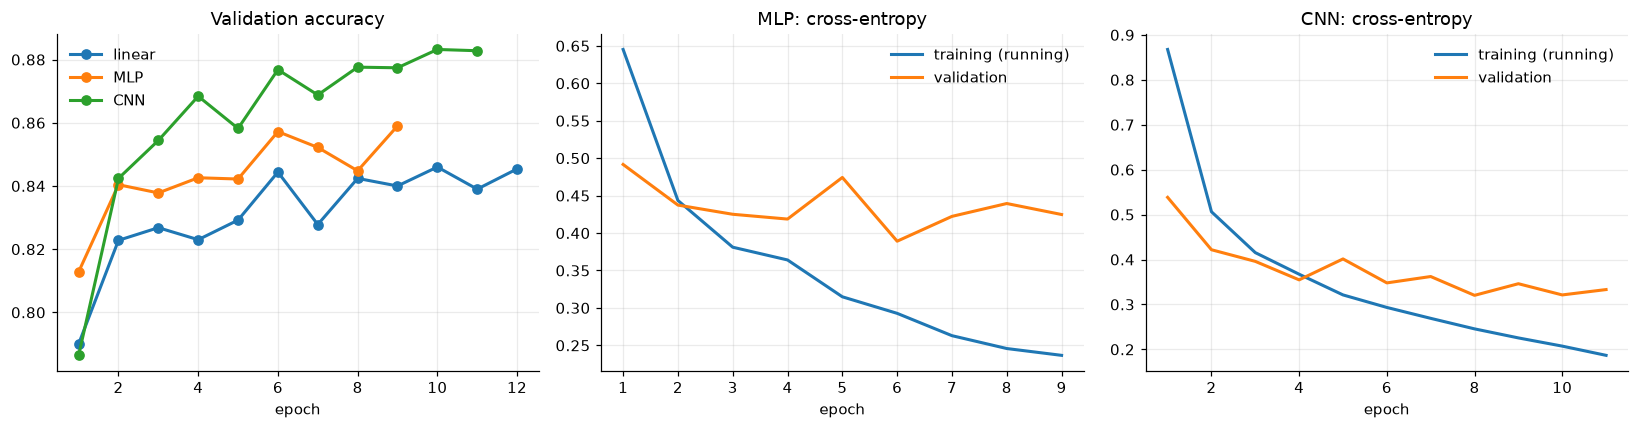


test accuracy per class:
              MLP   CNN  CNN - MLP
Shirt       0.690 0.652     -0.038
Coat        0.783 0.708     -0.075
T-shirt/top 0.715 0.821      0.106
Pullover    0.788 0.880      0.092
Dress       0.824 0.889      0.065
Sandal      0.916 0.951      0.035
Sneaker     0.923 0.960      0.037
Ankle boot  0.958 0.963      0.005
Bag         0.951 0.970      0.019
Trouser     0.971 0.980      0.009


In [10]:
# ────────────────────────────────────────────────────────────────────
# 1) Loop over MODELS. For each, take its history from HISTORIES, and find the best
#    epoch as the row with the lowest val_loss — the weights fit() restored.
# 2) Re-score the training set with evaluate() for a clean train_accuracy, and
#    score the test set once with evaluate(model, X_test, y_test).
# 3) One dict per model with the eight columns in the markdown; pd.DataFrame(rows).
# Search: "pandas DataFrame from list of dicts idxmin"
# https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.idxmin.html
#
# ١) كرّر على `MODELS`. ولكلٍّ منها خُذ سجلّه من `HISTORIES`، وجِد أفضل حقبة على أنها
#    الصف ذو أقل `val_loss` — وهي الأوزان التي استعادتها `fit()`.
# ٢) أعِد تقييم مجموعة التدريب بـ `evaluate()` لتحصل على `train_accuracy` نظيفة، وقِس
#    مجموعة الاختبار مرة واحدة بـ `evaluate(model, X_test, y_test)`.
# ٣) قاموس لكل نموذج بالأعمدة الثمانية في النصّ؛ ثم `pd.DataFrame(rows)`.
# ابحث عن: "pandas DataFrame from list of dicts idxmin"
# ────────────────────────────────────────────────────────────────────

MODELS = {"linear": linear, "MLP": mlp, "CNN": cnn}
HISTORIES = {"linear": linear_history, "MLP": mlp_history, "CNN": cnn_history}
# TODO: Build `comparison`: one row per model, with the test set scored exactly once.
# مهمة: ابنِ `comparison`: صف لكل نموذج، مع قياس مجموعة الاختبار مرة واحدة بالضبط.
comparison = []
for name, model in MODELS.items():
    history = HISTORIES[name]
    best_epoch = history.loc[history["val_loss"].idxmin()]
    train_loss, train_accuracy = evaluate(model, X_train, y_train)
    test_loss, test_accuracy = evaluate(model, X_test, y_test)
    comparison.append({
        "model": name,
        "train_loss": train_loss,
        "train_accuracy": train_accuracy,
        "val_loss": best_epoch["val_loss"],
        "val_accuracy": best_epoch["val_accuracy"],
        "test_loss": test_loss,
        "test_accuracy": test_accuracy,
        "parameters": count_parameters(model)
    })
comparison = pd.DataFrame(comparison) 

print(comparison.to_string(index=False, float_format=lambda v: f"{v:.4f}"))
test = comparison.set_index("model")["test_accuracy"]
print(f"\nCNN minus MLP: {test['CNN'] - test['MLP']:+.4f} of test accuracy, with "
      f"{count_parameters(cnn) / count_parameters(mlp):.0%} of the MLP's parameters")
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for (name, history), colour in zip(HISTORIES.items(), PALETTE):
    axes[0].plot(history["epoch"], history["val_accuracy"], color=colour,
                 linewidth=2, marker="o", label=name)
axes[0].set_title("Validation accuracy")
axes[0].set_xlabel("epoch")
axes[0].legend()
for ax, name in zip(axes[1:], ["MLP", "CNN"]):
    history = HISTORIES[name]
    ax.plot(history["epoch"], history["train_loss"], color=PALETTE[0], linewidth=2,
            label="training (running)")
    ax.plot(history["epoch"], history["val_loss"], color=PALETTE[1], linewidth=2,
            label="validation")
    ax.set_title(f"{name}: cross-entropy")
    ax.set_xlabel("epoch")
    ax.legend()
plt.tight_layout()
plt.show()
per_class = pd.DataFrame({name: [(predict(MODELS[name], X_test)[y_test == c] == c)
                                 .float().mean().item() for c in range(10)]
                          for name in ["MLP", "CNN"]}, index=CLASSES)
per_class["CNN - MLP"] = per_class["CNN"] - per_class["MLP"]
print("\ntest accuracy per class:")
print(per_class.sort_values("CNN").to_string(float_format=lambda v: f"{v:.3f}"))

**Read your own figure, and write it down** below, one or two sentences for each of these:

1. **Which of the four curve shapes** — diverging, flat, overfitting, healthy — is the MLP's loss curve,
   and which is the CNN's? Point at the evidence: the gap between training and validation, and whether
   the validation loss turned upwards.
2. **Parameters against accuracy.** The MLP has about four times the CNN's parameters. Where did the
   MLP's parameters go, and why did not one of them help it recognise "a sleeve, wherever it is"?
3. **The per-class table.** Which classes are hardest for both networks, and which class did convolution
   help most? Look at a few training images of that class before you answer. (Shirt, pullover and coat
   tend to be the hardest — look at them side by side and you will see why.)

<div dir="rtl" align="right">

**اقرأ شكلك أنت، واكتب ما تراه** أدناه، جملة أو جملتين لكلٍّ من هذه:

١. **أي أشكال المنحنيات الأربعة** — متباعد، ومسطّح، وفرط مطابقة، وسليم — هو منحنى خسارة الشبكة متعدّدة
   الطبقات، وأيّها منحنى الالتفافية؟ وأشِر إلى الدليل: الفجوة بين التدريب والتحقّق، وهل استدارت خسارة
   التحقّق صاعدة.
٢. **المعاملات مقابل الدقة.** للشبكة متعدّدة الطبقات نحو أربعة أضعاف معاملات الالتفافية. فأين ذهبت
   معاملاتها، ولماذا لم يُعِنها أيٌّ منها على التعرّف على «كمّ، أينما كان»؟
٣. **جدول الفئات.** أي الفئات أصعب على الشبكتين، وأي فئة أعانها الالتفاف أكثر؟ وانظر في بضع صور تدريب من
   تلك الفئة قبل أن تجيب. (القميص والبلوفر والمعطف هي عادةً الأصعب — انظر فيها جنبًا إلى جنب وستفهم لماذا.)

</div>


**Your answers:**

1. _Curve shapes:_
2. _Parameters against accuracy:_
3. _Per-class:_

<div dir="rtl" align="right">

**إجاباتك:**


١. _أشكال المنحنيات:_ منحنى الـ MLP **فرط مطابقة**: خسارة التدريب تنزل من ٠٫٦٥ إلى ٠٫٢٤ بينما التحقّق يتوقّف عند ٠٫٤٢ ويرتفع بعد الحقبة ٦، فالفجوة تتّسع. ومنحنى الـ CNN **سليم**: الخطّان ينزلان معًا والتحقّق ما زال هابطًا حتى آخر حقبة.

٢. _المعاملات مقابل الدقة:_ ٧٥٪ من معاملات الـ MLP (٤٠١٬٩٢٠ من ٥٣٥٬٨١٨) في الطبقة الأولى وحدها، لأنها تحتاج وزنًا مستقلًا لكل بكسل من الـ ٧٨٤ لكل عصبون من الـ ٥١٢. ولم يُعِنها أيٌّ منها على «كمّ أينما كان» لأن `nn.Flatten` يرمي ترتيب البكسلات من أول سطر، فالوزن الذي تعلّم كمًّا في الزاوية اليسرى لا يعرف شيئًا عن الزاوية اليمنى ولا ينقل تعلّمه إليها. أما الـ CNN فتمرّر النافذة نفسها (٣٢٠ معاملًا في أول التفاف) على كل المواضع، فتتعلّم النمط مرة وتستعمله في كل مكان.

٣. _الفئات:_ أصعب الفئات على الشبكتين هي القميص (0.652 و 0.690) والمعطف (0.708 و 0.783) والقميص العلوي — وكلها ملابس علوية ذات صورة ظلّية متشابهة جدًا عند ٢٨×٢٨. وأكثر فئة أعانها الالتفاف هي **T-shirt/top** بـ ‎+0.106‎، ثم Pullover بـ ‎+0.092‎. لكن المكسب الكلي ليس متجانسًا: فالـ CNN **أسوأ** في المعطف (‎-0.075‎) والقميص (‎-0.038‎)، أي أنها أعادت توزيع الخلط بين الملابس العلوية الخمس بدل أن تزيله.



</div>


### Task 2.5 — scramble the pixels, and find out who was using the picture

"Convolution works because it uses the arrangement of the pixels" is a claim. This task tests it.

Choose **one** random permutation of the 784 pixel positions and apply it to **every** image: the
pixel at position 0 moves to position 517, the one at 1 to position 88, and so on. It is the same
permutation for every image and every split, and the single grayscale channel moves accordingly.

Nothing is lost. Every image still has exactly the same 784 values, and you could undo the shuffle
exactly if you knew the permutation. The images now look like grayscale noise, but the information
that tells a sandal from a sneaker is all still there. The **only** thing destroyed is which pixel
was next to which.

`Scramble` is a tiny `nn.Module` that applies the permutation. Putting it first in an
`nn.Sequential` gives you a scrambled version of any model with no extra copies of the data in memory.
Train a scrambled MLP and a scrambled CNN with the same `fit()`, the same seed and the same budget.
Then score each once on the test set, scrambled the same way. **Predict both results before you run the
cell**, and write your prediction down.

<div dir="rtl" align="right">

### المهمة ٢٫٥ — اخلط البكسلات، واكتشف من كان يستخدم الصورة

«الالتفاف ينجح لأنه يستخدم ترتيب البكسلات» ادعاء. وهذه المهمة تختبره.

اختر تبديلًا عشوائيًا **واحدًا** لمواضع البكسلات الـ ٧٨٤ وطبّقه على **كل** صورة: البكسل في الموضع ٠ ينتقل إلى
الموضع ٥١٧، والذي في ١ إلى الموضع ٨٨، وهكذا. وهو التبديل نفسه لكل صورة ولكل تقسيم، والقناة الرمادية
الوحيدة تتحرّك معه.

ولا يضيع شيء. فكل صورة ما زالت فيها القيم الـ ٧٨٤ نفسها بالضبط، ويمكنك التراجع عن الخلط تمامًا لو عرفت
التبديل. وتبدو الصور الآن ضوضاء رمادية، لكن المعلومات التي تميّز الصندل من الحذاء الرياضي كلها ما زالت
فيها. والشيء **الوحيد** الذي يُدمَّر هو أي بكسل كان بجانب أيّ بكسل.

و`Scramble` وحدة `nn.Module` صغيرة تطبّق التبديل. ووضعها أولًا في `nn.Sequential` يعطيك نسخة مخلوطة من أي
نموذج بلا نسخ إضافية من البيانات في الذاكرة. درّب شبكة متعدّدة الطبقات مخلوطة وشبكة التفافية مخلوطة بـ `fit()`
نفسها والبذرة نفسها والميزانية نفسها. ثم قِس كلًّا منهما مرة واحدة على مجموعة الاختبار، مخلوطةً بالطريقة
نفسها. **توقّع النتيجتين قبل أن تشغّل الخليّة**، واكتب توقّعك.

</div>


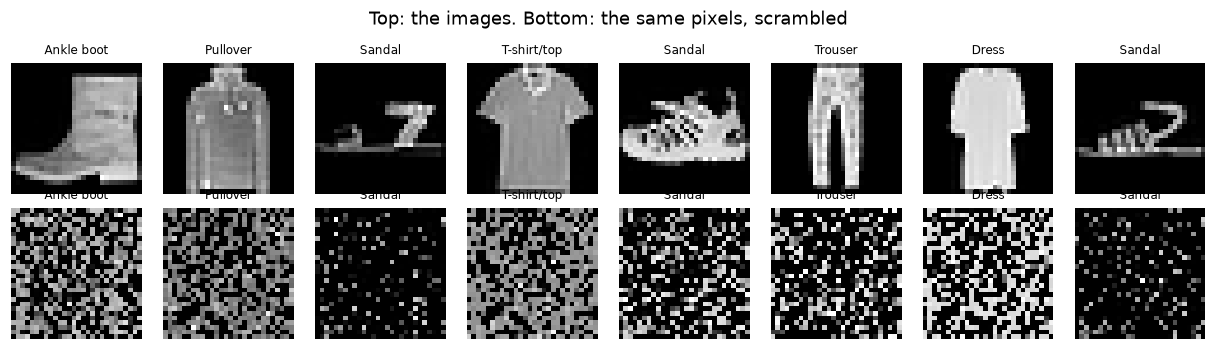

same values, new places: True
stopped after 9 epochs, best validation loss at epoch 6
stopped after 12 epochs, best validation loss at epoch 9
model  test_accuracy  scrambled_test_accuracy  change
  MLP        +0.8519                  +0.8516 -0.0003
  CNN        +0.8774                  +0.8378 -0.0396

scrambling cost the MLP 0.0003 and the CNN 0.0396 of test accuracy
scrambled CNN vs unscrambled MLP: -0.0141


In [15]:
# ────────────────────────────────────────────────────────────────────
# 1) For each of MLP and SmallCNN: torch.manual_seed(SEED), then
#    nn.Sequential(Scramble(PERMUTATION), MLP()) — the model sees scrambled images,
#    and nothing else changes.
# 2) fit() it exactly as before, then evaluate() it once on X_test. The Scramble at
#    the front scrambles the test images the same way.
# 3) Keep one row per network: its original test accuracy (from comparison), its
#    scrambled test accuracy, and the change. Keep each history too.
# Search: "pytorch nn.Sequential custom module permute pixels"
# https://pytorch.org/docs/stable/generated/torch.nn.Sequential.html
#
# ١) لكلٍّ من `MLP` و`SmallCNN`: `torch.manual_seed(SEED)` ثم
#    `nn.Sequential(Scramble(PERMUTATION), MLP())` — فيرى النموذج صورًا مخلوطة،
#    ولا يتغيّر شيء آخر.
# ٢) درّبه بـ `fit()` كما سبق تمامًا، ثم `evaluate()` مرة واحدة على `X_test`. و`Scramble`
#    في المقدّمة يخلط صور الاختبار بالطريقة نفسها.
# ٣) احتفظ بصف لكل شبكة: دقة اختبارها الأصلية (من `comparison`)، ودقتها المخلوطة،
#    والتغيّر. واحتفظ بكل سجلّ أيضًا.
# ابحث عن: "pytorch nn.Sequential custom module permute pixels"
# ────────────────────────────────────────────────────────────────────

PERMUTATION = torch.randperm(28 * 28, generator=torch.Generator().manual_seed(SEED))
class Scramble(nn.Module):
    """Move every pixel to a fixed new position — the same move for every image."""

    def __init__(self, permutation):
        super().__init__()
        self.permutation = permutation

    def forward(self, x):
        # (N, 1, 28, 28) -> (N, 1, 784), reorder the 784 positions, and back
        return x.flatten(2)[:, :, self.permutation].reshape(x.shape)
scrambled_view = Scramble(PERMUTATION)(X_train[:8])
plot_grid(show(torch.cat([X_train[:8], scrambled_view])),
          [CLASSES[i] for i in y_train[:8]] * 2, n_cols=8,
          title="Top: the images. Bottom: the same pixels, scrambled")
plt.show()
print(f"same values, new places: "
      f"{torch.equal(X_train[:8].flatten(2).sort(dim=2).values, scrambled_view.flatten(2).sort(dim=2).values)}")
# TODO: Train a scrambled MLP and a scrambled SmallCNN with fit(), score each once on the test set, and build `scrambled` — one row per network — plus `scrambled_histories`.
# مهمة: درّب `MLP` مخلوطة و`SmallCNN` مخلوطة بـ `fit()`، وقِس كلًّا منهما مرة واحدة على مجموعة الاختبار، وابنِ `scrambled` — صفًا لكل شبكة — و`scrambled_histories`.
ARCHITECTURES = {"MLP": MLP, "CNN": SmallCNN}

scrambled_models    = {}
scrambled_histories = {}
rows = []

for name, Architecture in ARCHITECTURES.items():
    torch.manual_seed(SEED)
    model = nn.Sequential(Scramble(PERMUTATION), Architecture())
    scrambled_models[name]    = model
    scrambled_histories[name] = fit(model)

    scrambled_accuracy = evaluate(model, X_test, y_test)[1]
    original = float(test[name])

    rows.append({
        "model":                   name,
        "test_accuracy":           original,
        "scrambled_test_accuracy": scrambled_accuracy,
        "change":                  scrambled_accuracy - original,
    })

scrambled = pd.DataFrame(rows)



print(scrambled.to_string(index=False, float_format=lambda v: f"{v:+.4f}"))
change = scrambled.set_index("model")["change"]
print(f"\nscrambling cost the MLP {-change['MLP']:.4f} and the CNN {-change['CNN']:.4f} "
      f"of test accuracy")
print(f"scrambled CNN vs unscrambled MLP: "
      f"{scrambled.set_index('model').loc['CNN', 'scrambled_test_accuracy'] - test['MLP']:+.4f}")

**What that shows.**

**The MLP did not notice**, and it could not have. Scrambling the input is the same as scrambling the
columns of the first layer's weight matrix: `x[perm] @ W.T` equals `x @ W[:, perm].T`, where
`W[:, perm]` is just a different set of starting weights, drawn from the same random distribution.
Adam updates each weight on its own, so it does not care about column order either. The scrambled MLP
is a normal MLP with a different random start. It moved by about a point here, but that is one run. Across five
seeds the scrambled MLP scores 0.838–0.855 and the ordinary one 0.852–0.856: the ranges overlap,
so most of that point is the luck of this seed. The CNN's drop is several times larger. **An MLP never used the arrangement of the pixels. It treats the image as 784
unrelated numbers whether or not you scramble them.**

**The CNN fell toward the MLP's level.** Its 3×3 filter now covers nine pixels that were scattered
across the whole image, so "neighbouring pixels belong together" is false. Sharing one filter
across positions buys nothing when position no longer means anything. It still learns something, since
the overall darkness of a scrambled image survives (a trouser leg is still mostly dark pixels), but
all of its advantage is gone: it lost more than its lead over the MLP.

So the architecture is a **bet about the data**. This bet has a name: the **inductive bias**. A CNN
bets that nearby pixels are related and that a pattern means the same thing wherever it appears. On
images like these the bet is right, and it lets the CNN learn more from 10,000 images with fewer
parameters. On data where the bet is wrong — a scrambled image, or the 23 columns of Monday's table,
where "column 4 is next to column 5" means nothing — convolution has nothing to offer. That is why
the tree or the MLP is the right tool there.

<div dir="rtl" align="right">

**ما يُظهره ذلك.**

**لم تلاحظ الشبكة متعدّدة الطبقات شيئًا**، وما كان لها أن تلاحظ. فخلط المُدخَل هو نفسه خلط أعمدة مصفوفة أوزان
الطبقة الأولى: `x[perm] @ W.T` يساوي `x @ W[:, perm].T`، و`W[:, perm]` ليست إلا مجموعة أخرى من الأوزان
الابتدائية، مسحوبة من التوزيع العشوائي نفسه. وAdam يحدّث كل وزن وحده، فلا يهمّه ترتيب الأعمدة أيضًا. فالشبكة
المخلوطة شبكة عادية ببداية عشوائية مختلفة. وقد تحرّكت هنا نحو نقطة، لكنه تشغيل واحد. فعبر خمس
بذور تسجّل الشبكة المخلوطة ٠٫٨٣٨–٠٫٨٥٥ والعادية ٠٫٨٥٢–٠٫٨٥٦: والمديان متداخلان،
فأكثر تلك النقطة حظّ هذه البذرة. أما هبوط الشبكة الالتفافية فأكبر بأضعاف. **فالشبكة متعدّدة الطبقات
لم تستخدم ترتيب البكسلات قطّ. بل تعامل الصورة على أنها ٧٨٤ رقمًا لا علاقة بينها، خلطتها أم لم تخلطها.**

**وهبطت الشبكة الالتفافية نحو مستوى الشبكة متعدّدة الطبقات.** ففِلترها ٣×٣ يغطّي الآن تسعة بكسلات كانت
متفرّقة في أنحاء الصورة كلها، فصار «البكسلات المتجاورة متّصلة» كاذبًا. ومشاركة فِلتر واحد بين المواضع لا تشتري
شيئًا حين لا يعود للموضع معنى. وما زالت تتعلّم شيئًا، لأن القتامة العامة للصورة المخلوطة تنجو (فساق البنطال
ما زال في معظمه بكسلات داكنة)، لكن تفوّقها ذهب كلّه: فقد خسرت أكثر من تقدّمها على الشبكة متعدّدة الطبقات.

فالمعمارية **رهان على البيانات**. ولهذا الرهان اسم: **الانحياز الاستقرائي (Inductive Bias)**. تراهن الشبكة
الالتفافية على أن البكسلات القريبة مترابطة، وأن النمط يعني الشيء نفسه أينما ظهر. وعلى صور كهذه الرهان
صحيح، ويتيح لها أن تتعلّم من عشرة آلاف صورة أكثر بمعاملات أقل. وعلى بيانات يكون فيها الرهان خاطئًا — صورة
مخلوطة، أو أعمدة جدول الاثنين الثلاثة والعشرين، حيث لا يعني «العمود ٤ بجانب العمود ٥» شيئًا — لا يملك الالتفاف
ما يقدّمه. ولهذا تكون الشجرة أو الشبكة متعدّدة الطبقات الأداة الصحيحة هناك.

</div>


**Your prediction, and what happened:** _(what you expected for each network before running task 2.5,
what you got, and one sentence on what an architecture assumes about its data)_

<div dir="rtl" align="right">

**توقّعك، وما حدث:** _(ما توقّعته لكل شبكة قبل تشغيل المهمة ٢٫٥، وما حصلت عليه، وجملة واحدة عمّا تفترضه
المعمارية عن بياناتها)_



توقّعت ألا تتأثّر الشبكة متعدّدة الطبقات إطلاقًا، لأن الخلط بالنسبة لها مجرّد إعادة ترتيب لأعمدة مصفوفة أوزانها الأولى — نفس الدالة بعناوين مختلفة — وتوقّعت أن تهبط الالتفافية ٣–٥ نقاط لأن نافذتها ٣×٣ تفترض أن البكسلات المتجاورة مترابطة.

وما حصل أقوى مما توقّعت: الشبكة متعدّدة الطبقات تحرّكت **‎-0.0003‎** فقط (من ٠٫٨٥١٩ إلى ٠٫٨٥١٦)، وهو صفر عمليًا. أما الالتفافية فهبطت **‎-0.0396‎** (من ٠٫٨٧٧٤ إلى ٠٫٨٣٧٨) — أي أنها لم تخسر تفوّقها البالغ ٢٫٥٥ نقطة فحسب، بل صارت **أدنى من الشبكة متعدّدة الطبقات بـ ١٫٤١ نقطة**. ولم تضع أي معلومة في التجربة: كل صورة فيها القيم الـ٧٨٤ نفسها (`same values, new places: True`)، والشيء الوحيد الذي كُسر هو الجوار.

والمعمارية **رهان على بنية البيانات**: الالتفافية تراهن أن البكسلات القريبة مترابطة وأن النمط يعني الشيء نفسه أينما ظهر، فإن صحّ الرهان تعلّمت أكثر بمعاملات أقل، وإن بطل — كما هنا — لم يبقَ لها ما تقدّمه.

</div>


## Section 3 — Stretch: what the first layers learned, and can today's regularisers rescue the MLP?  (≈30 min)

Open-ended. Lower expectation of completeness.

**3.1 — Draw the first layer of each network.** Every hidden unit in the MLP's first `nn.Linear` has
784 weights, one per input value. Reshaped to `(1, 28, 28)`, they are a picture the size of the
**whole image**: a template the unit compares every image with. Every filter in the CNN's first
`nn.Conv2d` has 9 weights, a picture 3×3 pixels wide, compared with every small patch. Draw 16 of each,
rescaling every one to `[0, 1]` on its own so its pattern is visible.

Expect the MLP's templates to look like faint ghosts of average garment shapes mixed with noise.
Expect the CNN's filters to be small edge and gradient detectors, even though nobody asked for edges.
W4D2 does the same with MNIST's filters.

**3.2 — One knob at a time, from the morning.** The MLP's validation loss turned upwards within a few
epochs, which is the overfitting shape. Today's theory has a fix for that: `nn.Dropout(0.5)` after each
hidden ReLU. Train that MLP and find out whether it closes any of the gap to the CNN — it may not. Then go
the other way:
put `nn.BatchNorm2d(c)` after each of the CNN's convolutions, where `c` is that conv's `out_channels`.
Measure both against their baselines on the validation set, change **one** thing each time, and add a
row for each to the experiment log.

<div dir="rtl" align="right">

## القسم الثالث — الإضافي: ماذا تعلّمت الطبقات الأولى، وهل تُنقذ مُنظِّمات اليوم الشبكة متعدّدة الطبقات؟ (نحو ٣٠ دقيقة)

مفتوح. والتوقّع في الإكمال أقل.

**٣٫١ — ارسم الطبقة الأولى في كل شبكة.** لكل وحدة مخفيّة في أول `nn.Linear` من الشبكة متعدّدة الطبقات ٧٨٤
وزنًا، واحد لكل قيمة مُدخَلة. وإن أعدت تشكيلها إلى `(1, 28, 28)` صارت صورة بحجم **الصورة كلها**: قالبًا
تقارن به الوحدة كل صورة. ولكل فِلتر في أول `nn.Conv2d` من الشبكة الالتفافية ٩ أوزان، صورة عرضها ٣×٣
بكسلات، تُقارَن بكل رقعة صغيرة. ارسم ١٦ من كلٍّ منهما، وأعِد قياس كل واحد إلى `[0, 1]` وحده ليظهر نمطه.

وتوقّع أن تبدو قوالب الشبكة متعدّدة الطبقات أشباحًا باهتة لأشكال ملابس وسطية مع ضوضاء. وتوقّع أن تكون فلاتر
الالتفافية كواشف صغيرة للحواف والميول، مع أن أحدًا لم يطلب حوافًا. ويفعل الأسبوع ٤ اليوم ٢ الشيء نفسه مع
فلاتر MNIST.

**٣٫٢ — مقبض واحد في كل مرة، من محاضرة الصباح.** استدارت خسارة التحقّق للشبكة متعدّدة الطبقات صاعدة خلال حقب
قليلة، وهذا شكل فرط المطابقة. ولنظرية اليوم علاج له: `nn.Dropout(0.5)` بعد كل ReLU مخفيّ. درّب تلك الشبكة واكتشف
هل تسدّ شيئًا من الفجوة إلى الالتفافية — وقد لا تسدّ. ثم اذهب في الاتجاه الآخر: ضَع `nn.BatchNorm2d(c)` بعد كل التفاف في الشبكة
الالتفافية، و`c` هو `out_channels` لذلك الالتفاف. قِس الاثنين مقابل خطَّي أساسهما على مجموعة التحقّق، وغيّر شيئًا
**واحدًا** في كل مرة، وأضِف صفًا لكلٍّ منهما إلى سجلّ التجارب.

</div>


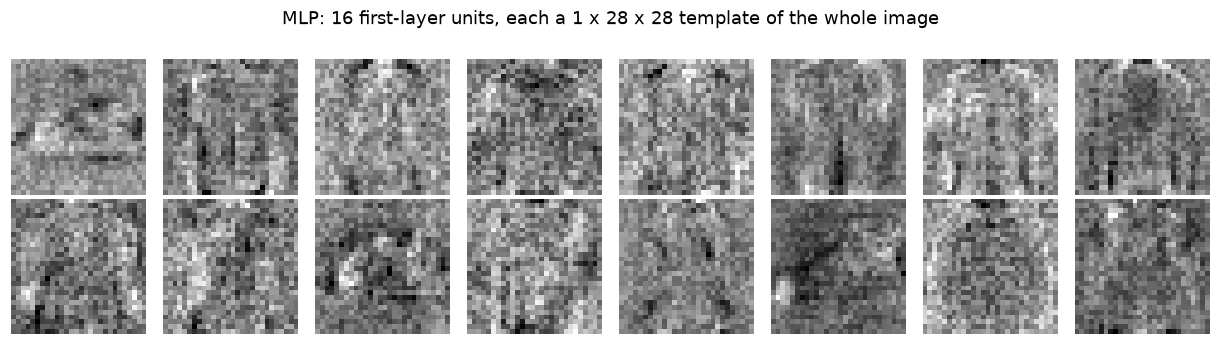

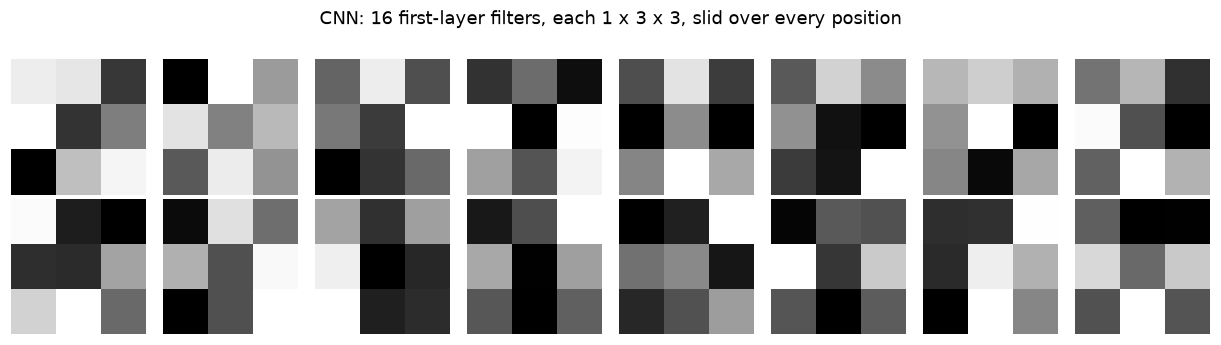

In [16]:
# ────────────────────────────────────────────────────────────────────
# 1) The MLP's first layer is mlp.net[1]; its .weight is (512, 784). Take 16 rows
#    and .view(16, 1, 28, 28). The CNN's is cnn.features[0].weight: (32, 1, 3, 3).
# 2) Rescale each picture to [0, 1] on its own: subtract its min, divide by its range.
#    amin/amax over dims (1, 2, 3) with keepdim=True does all 16 at once.
# 3) .detach() before drawing — these tensors carry gradients. plot_grid draws
#    (N, 1, H, W) as grayscale images.
# Search: "visualize first layer weights pytorch conv filters"
# https://cs231n.github.io/understanding-cnn/
#
# ١) الطبقة الأولى في الشبكة متعدّدة الطبقات هي `mlp.net[1]`، و`.weight` شكلها (512, 784).
#    خُذ ١٦ صفًا ثم `.view(16, 1, 28, 28)`. وفي الالتفافية `cnn.features[0].weight`: (32, 1, 3, 3).
# ٢) أعِد قياس كل صورة إلى `[0, 1]` وحدها: اطرح أصغر قيمة فيها واقسم على مداها.
#    و`amin`/`amax` على الأبعاد (1, 2, 3) مع `keepdim=True` تفعل الست عشرة معًا.
# ٣) `.detach()` قبل الرسم — فهذه المُوتِّرات تحمل اشتقاقات. و`plot_grid` ترسم
#    (N, 1, H, W) صورًا رمادية.
# ابحث عن: "visualize first layer weights pytorch conv filters"
# ────────────────────────────────────────────────────────────────────

def rescale(pictures):
    low = pictures.amin(dim=(1, 2, 3), keepdim=True)
    high = pictures.amax(dim=(1, 2, 3), keepdim=True)
    return (pictures - low) / (high - low)
# TODO: Take 16 MLP first-layer templates and 16 CNN first-layer filters as (16, 1, H, W).
# مهمة: خُذ ١٦ قالبًا من الطبقة الأولى للشبكة متعدّدة الطبقات و١٦ فِلترًا من أول التفاف بشكل (16, 1, H, W).
mlp_templates = mlp.net[1].weight[:16].view(16, 1, 28, 28).detach()
cnn_filters = cnn.features[0].weight[:16].detach()


plot_grid(rescale(mlp_templates), n_cols=8,
          title="MLP: 16 first-layer units, each a 1 x 28 x 28 template of the whole image")
plt.show()
plot_grid(rescale(cnn_filters), n_cols=8,
          title="CNN: 16 first-layer filters, each 1 x 3 x 3, slid over every position")
plt.show()

In [17]:
# ────────────────────────────────────────────────────────────────────
# 1) The dropout MLP: the same layers as MLP, with nn.Dropout(0.5) after each hidden
#    ReLU. The batch-norm CNN: SmallCNN's layers with nn.BatchNorm2d(c) after each
#    Conv2d. Build each as an nn.Sequential, seeded right before.
# 2) fit() both exactly as before. fit() already switches train() and eval(),
#    which dropout and batch norm both depend on — that is why it has to.
# 3) Compare validation accuracy only. The test set was for task 2.4.
# Search: "pytorch nn.Dropout nn.BatchNorm2d CNN FashionMNIST"
# https://pytorch.org/docs/stable/generated/torch.nn.BatchNorm2d.html
#
# ١) الشبكة متعدّدة الطبقات مع Dropout: طبقات `MLP` نفسها مع `nn.Dropout(0.5)` بعد كل
#    ReLU مخفيّ. والالتفافية مع تطبيع الدفعات: طبقات `SmallCNN` مع `nn.BatchNorm2d(c)` بعد
#    كل `Conv2d`. وابنِ كلًّا منهما كـ `nn.Sequential` مبذورًا قبله مباشرة.
# ٢) درّب الاثنتين بـ `fit()` كما سبق تمامًا. و`fit()` تبدّل بين `train()` و`eval()`
#    أصلًا، ويعتمد عليهما Dropout وتطبيع الدفعات كلاهما — ولهذا يجب أن تفعل.
# ٣) قارن دقة التحقّق وحدها. فمجموعة الاختبار كانت للمهمة ٢٫٤.
# ابحث عن: "pytorch nn.Dropout nn.BatchNorm2d CNN FashionMNIST"
# ────────────────────────────────────────────────────────────────────

# TODO: Build a dropout MLP and a batch-norm CNN, train each with fit(), and collect `stretch` — one row per run with its baseline's validation accuracy beside it.
# مهمة: ابنِ شبكة متعدّدة الطبقات مع Dropout وشبكة التفافية مع تطبيع الدفعات، ودرّب كلًّا منهما بـ `fit()`، واجمع `stretch` — صفًا لكل تشغيل بجانبه دقة تحقّق خط أساسه.
torch.manual_seed(SEED)
dropout_mlp = nn.Sequential(
    nn.Flatten(),
    nn.Linear(1 * 28 * 28, 512), nn.ReLU(), nn.Dropout(0.5),
    nn.Linear(512, 256),         nn.ReLU(), nn.Dropout(0.5),
    nn.Linear(256, 10),
)
dropout_history = fit(dropout_mlp)

torch.manual_seed(SEED)
batchnorm_cnn = nn.Sequential(
    nn.Conv2d(1, 32, 3, padding=1),  nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
    nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
    nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
    nn.Flatten(), nn.Linear(64 * 3 * 3, 128), nn.ReLU(), nn.Linear(128, 10),
)
batchnorm_history = fit(batchnorm_cnn)

stretch = pd.DataFrame([
    {"run":        "MLP + dropout(0.5)",
     "model":      dropout_mlp,
     "history":    dropout_history,
     "parameters": count_parameters(dropout_mlp),
     "epochs_run": len(dropout_history),
     "baseline_val_accuracy": float(comparison.set_index("model").loc["MLP", "val_accuracy"]),
     "val_accuracy": evaluate(dropout_mlp, X_val, y_val)[1]},

    {"run":        "CNN + batch norm",
     "model":      batchnorm_cnn,
     "history":    batchnorm_history,
     "parameters": count_parameters(batchnorm_cnn),
     "epochs_run": len(batchnorm_history),
     "baseline_val_accuracy": float(comparison.set_index("model").loc["CNN", "val_accuracy"]),
     "val_accuracy": evaluate(batchnorm_cnn, X_val, y_val)[1]},
])


print(stretch[["run", "parameters", "epochs_run", "baseline_val_accuracy",
               "val_accuracy"]].to_string(index=False, float_format=lambda v: f"{v:.4f}"))

stopped after 7 epochs, best validation loss at epoch 4
               run  parameters  epochs_run  baseline_val_accuracy  val_accuracy
MLP + dropout(0.5)      535818          12                 0.8572        0.8632
  CNN + batch norm      131210           7                 0.8776        0.8854


**Your closing answers.** The second one is the week's exit question.

1. Did dropout close the gap between the MLP and the CNN, narrow it, or make the MLP worse? Look at
   `epochs_run` too: did the dropout MLP simply run out of epochs? Then say what this tells you about
   the difference between a model that **overfits** and a model that is **the wrong shape for its
   data** — and why batch norm, on the CNN, is a different kind of change.
2. **Given this week's numbers** — Monday's tree on a table, Thursday's network on two coordinates, and
   today's two families on images, scrambled and not — what kind of data would you use a CNN for,
   what kind an MLP, and what kind a tree? Give the reason each time as an assumption about the data.

<div dir="rtl" align="right">

**إجاباتك الختامية.** والثانية هي سؤال خروج الأسبوع.

١. هل سدّ Dropout الفجوة بين الشبكة متعدّدة الطبقات والالتفافية، أم ضيّقها، أم أساء الشبكة؟ وانظر في
   `epochs_run` أيضًا: هل نفدت الحقب من الشبكة ذات Dropout ببساطة؟ ثم قُل ماذا يقول لك ذلك عن الفرق بين نموذج
   **يُفرط في المطابقة** ونموذج **شكله خاطئ لبياناته** — ولماذا يكون تطبيع الدفعات، على الالتفافية، تغييرًا من
   نوع آخر.
٢. **بالنظر إلى أرقام هذا الأسبوع** — شجرة الاثنين على جدول، وشبكة الخميس على إحداثيين، وعائلتا اليوم على الصور،
   مخلوطةً وغير مخلوطة — لأي نوع من البيانات تستخدم شبكة التفافية، ولأيّه شبكة متعدّدة الطبقات، ولأيّه شجرة؟
   واذكر السبب في كل مرة افتراضًا عن البيانات.

</div>


<div dir="rtl" align="right">

 **الشبكة الالتفافية** للبيانات الي لترتيبها معنى مكاني — صور، إشارات، سلاسل زمنية. لأنها تفترض شيئين: البكسلات المتجاورة مترابطة، والنمط نفسه يعني الشي نفسه في أي مكان من الصورة. وشفت الافتراض يصحّ اليوم (‎+2.55‎ نقطة بربع المعاملات)، ويطيح لما خلطت البكسلات (‎-3.96‎ نقطة، ونزلت تحت الـ MLP).

**الشبكة متعدّدة الطبقات** للأرقام المتّصلة الي ما بينها ترتيب مكاني، لكن علاقتها بالهدف منحنية — مثل إحداثيَي يوم الخميس الي احتاجوا حدًّا منحنيًا (٠٫٩٨ مقابل ٠٫٨٦ لخط مستقيم). وهي ما تفترض إلا إن كل مُدخَل يأثّر على المُخرَج بشكل ما، وهذا افتراض عام جدًا — ولهذا الخلط ما أثّر فيها إطلاقًا (‎-0.0003‎).

**الشجرة أو التعزيز** للجداول الي أعمدتها أنواع ومقاييس مختلفة، وتجاورها ما يعني شي — مثل جدول الاثنين بـ ٢٣ عمودًا، حيث «العمود ٤ بجانب العمود ٥» ما له معنى. وهي تفترض إن القرار يُتخذ بعتبات على أعمدة مفردة، وهذا يناسب الجداول بالضبط — ولهذا التعزيز تجاوز اللوجستي هناك (٠٫٧٨١ مقابل ٠٫٧٢٣).

</div>

## Save your artefacts

Two files, and the first one is the capstone's requirement in miniature.

- **`experiments.parquet`** — one row per training run today, with every setting that could differ
  between runs: the architecture, whether the pixels were scrambled, the parameter count, the optimiser
  settings, the seed, the epochs run, and the validation and test accuracy. **The capstone brief
  released today asks for exactly this kind of table.** A report that says "we tried a CNN and it was
  better" cannot be checked. A report that ships this file can.
- **`best_model.pt`** — the CNN's weights, **plus everything needed to use them**: the config to rebuild
  the architecture, the normalisation constants the inputs must go through, and the class names in
  label order. Weights without their preprocessing are not a model. Feed this CNN images normalised with
  different numbers and it will be confidently wrong, with no error message to warn you.

Then the cell reloads the checkpoint into a fresh `SmallCNN` and checks it reproduces the recorded
validation accuracy exactly. A checkpoint nobody has reloaded is a checkpoint that does not work yet.

<div dir="rtl" align="right">

## احفظ مخرجاتك

ملفان، والأول هو متطلّب مشروع التخرّج مصغّرًا.

- **`experiments.parquet`** — صف لكل تشغيل تدريب اليوم، وفيه كل إعداد يمكن أن يختلف بين التشغيلات: المعمارية،
  وهل خُلطت البكسلات، وعدد المعاملات، وإعدادات المُحسِّن، والبذرة، والحقب التي عملت، ودقة التحقّق والاختبار.
  **وكرّاسة مشروع التخرّج المنشورة اليوم تطلب هذا النوع من الجداول بالضبط.** فالتقرير الذي يقول «جرّبنا شبكة
  التفافية فكانت أفضل» لا يمكن التحقّق منه، والذي يُرفق هذا الملف يمكن.
- **`best_model.pt`** — أوزان الشبكة الالتفافية، **ومعها كل ما يلزم لاستخدامها**: الإعداد لإعادة بناء
  المعمارية، وثوابت التطبيع التي يجب أن تمرّ فيها المُدخلات، وأسماء الفئات بترتيب التصنيفات. فالأوزان بلا معالجتها
  المسبقة ليست نموذجًا. وإن أطعمت هذه الشبكة صورًا مُطبَّعة بأرقام أخرى أخطأت خطأً واثقًا، بلا رسالة خطأ تُنبّهك.

ثم تُعيد الخليّة تحميل نقطة الحفظ في `SmallCNN` جديدة، وتتحقّق من أنها تُعيد إنتاج دقة التحقّق المسجّلة بالضبط.
فنقطة الحفظ التي لم يُعِد أحد تحميلها نقطة حفظ لا تعمل بعد.

</div>


In [18]:
def log_row(run, model, history, scrambled_pixels, test_accuracy):
    return {"run": run, "scrambled_pixels": scrambled_pixels,
            "parameters": count_parameters(model), "optimiser": "adam", "lr": LR,
            "batch_size": BATCH_SIZE, "max_epochs": EPOCHS, "patience": PATIENCE, "seed": SEED,
            "train_images": N_TRAIN, "epochs_run": len(history),
            "best_epoch": int(history.loc[history["val_loss"].idxmin(), "epoch"]),
            "val_accuracy": evaluate(model, X_val, y_val)[1],
            "test_accuracy": test_accuracy,
            "seconds_per_epoch": float(history["seconds"].mean())}


log = [log_row(name, MODELS[name], HISTORIES[name], False, test[name]) for name in MODELS]
log += [log_row(name, scrambled_models[name], scrambled_histories[name], True,
                float(scrambled.set_index("model").loc[name, "scrambled_test_accuracy"]))
        for name in scrambled_models]
if "stretch" in globals():   # Section 3 is optional; its runs are validation-only
    log += [log_row(row["run"], row["model"], row["history"], False, float("nan"))
            for _, row in stretch.iterrows()]
experiments = pd.DataFrame(log)
experiments_path = ARTEFACT_DIR / "experiments.parquet"
experiments.to_parquet(experiments_path, index=False)

recorded_accuracy = evaluate(cnn, X_val, y_val)[1]
model_path = ARTEFACT_DIR / "best_model.pt"
torch.save({"state_dict": cnn.state_dict(),
            "architecture": "SmallCNN",
            "config": {"in_channels": 1, "n_classes": 10},
            "transform": {"mean": FMNIST_MEAN, "std": FMNIST_STD},
            "classes": CLASSES,
            "val_accuracy": recorded_accuracy,
            "test_accuracy": float(test["CNN"])},
           model_path)

# Reload from scratch — a checkpoint nobody reloaded is a checkpoint that does not work.
checkpoint = torch.load(model_path)
rebuilt = SmallCNN(**checkpoint["config"])
rebuilt.load_state_dict(checkpoint["state_dict"])
reloaded_accuracy = evaluate(rebuilt, X_val, y_val)[1]

print(f"Saved {experiments_path}")
print(experiments[["run", "scrambled_pixels", "parameters", "epochs_run", "val_accuracy",
                   "test_accuracy"]].to_string(index=False, float_format=lambda v: f"{v:.4f}"))
print(f"\nSaved {model_path}")
print(f"  config: {checkpoint['config']} | normalisation: mean "
      f"{[round(m, 4) for m in checkpoint['transform']['mean']]}")
print(f"  recorded validation accuracy: {recorded_accuracy:.6f}")
print(f"  reloaded validation accuracy: {reloaded_accuracy:.6f}")
print(f"  reproduces exactly: {recorded_accuracy == reloaded_accuracy}")

Saved /Users/leen/AIEP_Olo_student/week_3_neural_networks/labs/D5_linear_vs_conv/artefacts/experiments.parquet
               run  scrambled_pixels  parameters  epochs_run  val_accuracy  test_accuracy
            linear             False        7850          12        0.8454         0.8333
               MLP             False      535818           9        0.8572         0.8519
               CNN             False      130890          11        0.8776         0.8774
               MLP              True      535818           9        0.8588         0.8516
               CNN              True      130890          12        0.8562         0.8378
MLP + dropout(0.5)             False      535818          12        0.8632            NaN
  CNN + batch norm             False      131210           7        0.8854            NaN

Saved /Users/leen/AIEP_Olo_student/week_3_neural_networks/labs/D5_linear_vs_conv/artefacts/best_model.pt
  config: {'in_channels': 1, 'n_classes': 10} | normalisation: 

## Sanity check

Run this last. Every check that fails tells you what to fix and why.

The comparison checks are **bands, not exact numbers**, because your runs depend on your machine. They
are still tight enough to fail on the plausible mistakes: a CNN whose channels do not chain, a `fit()`
that forgets to restore the best weights, or a scramble that was not applied to the test images.

<div dir="rtl" align="right">

## فحص النتائج

شغّل هذه الخليّة أخيرًا. كل فحص يفشل يخبرك بما تُصلحه ولماذا.

وفحوص المقارنة **نطاقات لا أرقام دقيقة**، لأن تشغيلاتك تعتمد على جهازك. لكنها ضيّقة بما يكفي لتفشل عند الأخطاء
المعقولة: شبكة التفافية لا تتسلسل قنواتها، أو `fit()` تنسى استعادة أفضل الأوزان، أو خلط لم يُطبَّق على صور
الاختبار.

</div>


In [19]:
# --- Sanity checks ----------------------------------------------------------------

channel_means = X_train.mean(dim=(0, 2, 3))
channel_stds = X_train.std(dim=(0, 2, 3))
rounded = lambda t: [round(v, 4) for v in t.tolist()]
check(channel_means.abs().max() < 0.01 and (channel_stds - 1).abs().max() < 0.01,
      f"after Normalize, the training channel should have mean ~0 and std ~1 — got means "
      f"{rounded(channel_means)} and stds {rounded(channel_stds)}. "
      f"Were the mean and std computed per channel, on the training images?",
      f"بعد `Normalize` يجب أن يكون للقناة التدريبية متوسط قرب ٠ وانحراف قرب ١ — والناتج متوسطات "
      f"{rounded(channel_means)} وانحرافات {rounded(channel_stds)}. "
      f"هل حُسب المتوسط والانحراف لكل قناة، على صور التدريب؟")

initial = {name: round(float(HISTORIES[name]["initial_loss"].iloc[0]), 4) for name in HISTORIES}
check(all(abs(v - math.log(10)) < 0.2 for v in initial.values()),
      f"every model should start near ln 10 = 2.3026, the loss of knowing nothing about ten "
      f"classes — got {initial}. A model that starts far "
      f"from it is confident before it has learned anything — usually inputs that skipped "
      f"Normalize (pixels of 0-255 make huge logits).",
      f"يجب أن يبدأ كل نموذج قرب ln 10 = 2.3026، خسارة من لا يعرف شيئًا عن عشر فئات — والناتج "
      f"{initial}. فالنموذج الذي يبدأ بعيدًا عنه واثقٌ قبل أن "
      f"يتعلّم شيئًا — وكثيرًا ما تكون مُدخلات لم تمرّ في `Normalize` (فبكسلات ٠-٢٥٥ تصنع logits ضخمة).")

first_conv = cnn.features[0]
check(tuple(first_conv.weight.shape) == (32, 1, 3, 3)
      and tuple(cnn.features(X_train[:1]).shape) == (1, 64, 3, 3)
      and count_parameters(cnn) < count_parameters(mlp) / 3,
      f"SmallCNN should start with Conv2d(1, 32, 3) — weight (32, 1, 3, 3), got "
      f"{tuple(first_conv.weight.shape)} — end its features at (1, 64, 3, 3), got "
      f"{tuple(cnn.features(X_train[:1]).shape)}, and have under a third of the MLP's parameters "
      f"({count_parameters(cnn):,} vs {count_parameters(mlp):,})",
      f"يجب أن تبدأ `SmallCNN` بـ `Conv2d(1, 32, 3)` — وزن (32, 1, 3, 3)، والناتج "
      f"{tuple(first_conv.weight.shape)} — وأن تنتهي خصائصها عند (1, 64, 3, 3)، والناتج "
      f"{tuple(cnn.features(X_train[:1]).shape)}، وأن يكون لها أقل من ثلث معاملات الشبكة متعدّدة "
      f"الطبقات ({count_parameters(cnn):,} مقابل {count_parameters(mlp):,})")

restored_val_loss = evaluate(cnn, X_val, y_val)[0]
check(math.isclose(restored_val_loss, cnn_history["val_loss"].min(), abs_tol=1e-6),
      f"fit() must hand back the BEST epoch's weights: the CNN's validation loss now is "
      f"{restored_val_loss:.6f}, but its best epoch recorded {cnn_history['val_loss'].min():.6f}. "
      f"Did you forget model.load_state_dict(best_state)?",
      f"يجب أن تُرجع `fit()` أوزان **أفضل** حقبة: خسارة تحقّق الشبكة الالتفافية الآن "
      f"{restored_val_loss:.6f}، وأفضل حقبة سجّلت {cnn_history['val_loss'].min():.6f}. "
      f"هل نسيت `model.load_state_dict(best_state)`؟")

check(test["linear"] < test["MLP"] <= test["CNN"] and test["CNN"] - test["MLP"] > 0.01
      and 0.82 < test["CNN"] < 0.95,
      f"on the test set expect linear < MLP <= CNN, the CNN at least 1 point ahead of the MLP and "
      f"between 0.82 and 0.95 — got linear {test['linear']:.4f}, MLP {test['MLP']:.4f}, "
      f"CNN {test['CNN']:.4f}",
      f"على مجموعة الاختبار توقّع الخطّي < متعدّدة الطبقات ≤ الالتفافية، والالتفافية متقدّمة نقطة واحدة "
      f"على الأقل وبين ٠٫٨٢ و٠٫٩٥ — والناتج الخطّي {test['linear']:.4f}، ومتعدّدة الطبقات "
      f"{test['MLP']:.4f}، والالتفافية {test['CNN']:.4f}")

check(abs(change["MLP"]) < 0.03 and change["CNN"] < -0.02,
      f"scrambling the pixels should leave the MLP within 3 points (change {change['MLP']:+.4f}) and "
      f"cost the CNN at least 2 (change {change['CNN']:+.4f}). If the CNN did not drop, check that "
      f"Scramble sits first in its nn.Sequential and the test images went through it.",
      f"يجب أن يُبقي خلط البكسلات الشبكة متعدّدة الطبقات ضمن ٣ نقاط (التغيّر {change['MLP']:+.4f}) وأن يكلّف "
      f"الالتفافية نقطتين على الأقل (التغيّر {change['CNN']:+.4f}). فإن لم تهبط الالتفافية فتحقّق أن `Scramble` "
      f"أول ما في `nn.Sequential` وأن صور الاختبار مرّت فيه.")

check(len(experiments) >= 5 and experiments["test_accuracy"].notna().sum() >= 5
      and recorded_accuracy == reloaded_accuracy,
      f"experiments.parquet needs at least the five core runs with test scores (has "
      f"{experiments['test_accuracy'].notna().sum()}), and best_model.pt must reload to exactly its "
      f"recorded validation accuracy ({recorded_accuracy:.6f} vs {reloaded_accuracy:.6f})",
      f"يحتاج `experiments.parquet` التشغيلات الأساسية الخمسة على الأقل بنتائج اختبارها (فيه "
      f"{experiments['test_accuracy'].notna().sum()})، ويجب أن يُعاد تحميل `best_model.pt` إلى دقة تحقّقه "
      f"المسجّلة بالضبط ({recorded_accuracy:.6f} مقابل {reloaded_accuracy:.6f})")

report()

──────────────────────────────────────────────────────────────────
  ✓  after Normalize, the training channel should have mean ~0 and std ~1 — got means [0.0] and stds [1.0]. Were the mean and std computed per channel, on the training images?
  ✓  every model should start near ln 10 = 2.3026, the loss of knowing nothing about ten classes — got {'linear': 2.4296, 'MLP': 2.3283, 'CNN': 2.3034}. A model that starts far from it is confident before it has learned anything — usually inputs that skipped Normalize (pixels of 0-255 make huge logits).
  ✓  SmallCNN should start with Conv2d(1, 32, 3) — weight (32, 1, 3, 3), got (32, 1, 3, 3) — end its features at (1, 64, 3, 3), got (1, 64, 3, 3), and have under a third of the MLP's parameters (130,890 vs 535,818)
  ✓  fit() must hand back the BEST epoch's weights: the CNN's validation loss now is 0.320231, but its best epoch recorded 0.320231. Did you forget model.load_state_dict(best_state)?
  ✓  on the test set expect linear < MLP <= CNN, the C

## What's next

That is week 3. You arrived able to call `.fit()`. You leave having built what `.fit()` calls out of
bare tensors, checked its gradients against a numerical estimate, rebuilt it from PyTorch's layers, and
today pointed two families of it at images and measured the difference honestly.

Today's finding is worth carrying: **an architecture is an assumption about the data.** The MLP assumes
nothing about which inputs belong together, so scrambling cost it nothing. The CNN assumes nearby pixels
belong together and patterns repeat across the image. On Fashion-MNIST that assumption is true, and it
bought a few points of test accuracy with a quarter of the parameters. On CIFAR-10 or ImageNet the same
assumption pays off much more — this lab is the small, fast demonstration of a mechanism that scales.

Next week (**W4D1**) opens the layer you used as a black box today. You will write the convolution
yourself with two loops, first on the lecture's 5×5 grid and then on a real colour photograph, and the
`(n + 2p − k) // s + 1` from task 1.1 becomes something you derive rather than use. W4D2 builds a CNN
whose flatten size is computed instead of typed, W4D4 uses the random transforms you skipped today, and
W4D5 loads a network from `torchvision.models` that someone else trained on a million images.

Three things travel with you:

- **The five-line loop and `fit()`**, unchanged, for every model in weeks 4 to 7.
- **`experiments.parquet`** — the shape of the log your capstone report needs. The brief is out today.
  Read it tonight, and start the log on day one, not the night before submission.
- **The shape arithmetic.** `(batch, channels, height, width)`, the output-size formula, and the
  parameter count of a conv layer. You will use all three in every vision lab from here.

<div dir="rtl" align="right">

## ماذا بعد

هذا هو الأسبوع الثالث. وصلت وأنت تعرف مناداة `.fit()`. وتخرج وقد بنيت ما تناديه `.fit()` من مُوتِّرات عارية،
وتحقّقت من اشتقاقاته مقابل تقدير عددي، وأعدت بناءه من طبقات PyTorch، ووجّهت اليوم عائلتين منه إلى الصور وقِست
الفرق قياسًا صادقًا.

ونتيجة اليوم جديرة بالحمل: **المعمارية افتراض عن البيانات.** فالشبكة متعدّدة الطبقات لا تفترض شيئًا عن أي
المُدخلات متّصلة، فلم يكلّفها الخلط شيئًا. والالتفافية تفترض أن البكسلات القريبة متّصلة وأن الأنماط تتكرّر في أنحاء
الصورة. وعلى Fashion-MNIST ذلك الافتراض صحيح، واشترى نقاطًا قليلة من دقة الاختبار بربع المعاملات. وعلى
CIFAR-10 أو ImageNet يُؤتي الافتراض نفسه ثمارًا أكبر بكثير — وهذا المعمل هو العرض الصغير السريع لآلية تتوسّع.

وفي الأسبوع القادم (**الأسبوع ٤ اليوم ١**) تفتح الطبقة التي استخدمتها اليوم صندوقًا مغلقًا. ستكتب الالتفاف
بنفسك بحلقتين، أولًا على شبكة المحاضرة ٥×٥ ثم على صورة ملوّنة حقيقية، ويصير `(n + 2p − k) // s + 1` من
المهمة ١٫١ شيئًا تشتقّه لا تستخدمه فحسب. ويبني الأسبوع ٤ اليوم ٢ شبكة التفافية يُحسب حجم تسطيحها بدل أن
يُكتب، ويستخدم الأسبوع ٤ اليوم ٤ التحويلات العشوائية التي تخطّيتها اليوم، ويُحمّل الأسبوع ٤ اليوم ٥ شبكة من
`torchvision.models` درّبها غيرك على مليون صورة.

وثلاثة أمور تسافر معك:

- **حلقة الأسطر الخمسة و`fit()`** بلا تغيير، لكل نموذج في الأسابيع من الرابع إلى السابع.
- **`experiments.parquet`** وهو شكل السجلّ الذي يحتاجه تقرير مشروع تخرّجك. والكرّاسة صدرت اليوم، فاقرأها الليلة،
  وابدأ السجلّ من اليوم الأول لا في ليلة التسليم.
- **حساب الأشكال.** `(batch, channels, height, width)`، ومعادلة حجم المُخرَج، وعدد معاملات الطبقة الالتفافية.
  وستستخدم الثلاثة في كل معمل رؤية من هنا.

</div>
